# Rectified Flow
This jupyter notebook contains simple tutorial code for Rectified Flow proposed in '[Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow](https://arxiv.org/abs/2209.03003)'.

The problem here is to learn an ODE $\dot Z_t = v(Z_t, t) $ to transfer data from $\pi_0$ to $\pi_1$, where both $\pi_0$ and $\pi_1$ are unknown and empirically observed through a set of points.

The velocity field $v(z,t)$ in rectified flow can be fitted with either kernel method or deep neural networks. This tutorial illustrates the use of a neural network.

## Generating Distribution $\pi_0$ and $\pi_1$
We generate $\pi_0$ and $\pi_1$ as two Gaussian mixture models with different modes.

We sample 10000 data points from $\pi_0$ and $\pi_1$, respectively,
and store them in ```samples_0```, ```samples_1```.

In [1]:
# import torch
# import numpy as np
# import torch.nn as nn
# from torch.distributions import Normal, Categorical
# from torch.distributions.multivariate_normal import MultivariateNormal
# from torch.distributions.mixture_same_family import MixtureSameFamily
# import matplotlib.pyplot as plt
# import torch.nn.functional as F

# D = 10.
# M = D+5
# VAR = 0.3
# DOT_SIZE = 4
# COMP = 3

# initial_mix = Categorical(torch.tensor([1/COMP for i in range(COMP)]))
# initial_comp = MultivariateNormal(torch.tensor([[D * np.sqrt(3) / 2., D / 2.], [-D * np.sqrt(3) / 2., D / 2.], [0.0, - D * np.sqrt(3) / 2.]]).float(), VAR * torch.stack([torch.eye(2) for i in range(COMP)]))
# initial_model = MixtureSameFamily(initial_mix, initial_comp)
# samples_0 = initial_model.sample([10000])

# target_mix = Categorical(torch.tensor([1/COMP for i in range(COMP)]))
# target_comp = MultivariateNormal(torch.tensor([[D * np.sqrt(3) / 2., - D / 2.], [-D * np.sqrt(3) / 2., - D / 2.], [0.0, D * np.sqrt(3) / 2.]]).float(), VAR * torch.stack([torch.eye(2) for i in range(COMP)]))
# target_model = MixtureSameFamily(target_mix, target_comp)
# samples_1 = target_model.sample([10000])
# print('Shape of the samples:', samples_0.shape, samples_1.shape)

# plt.figure(figsize=(4,4))
# plt.xlim(-M,M)
# plt.ylim(-M,M)
# plt.title(r'Samples from $\pi_0$ and $\pi_1$')
# plt.scatter(samples_0[:, 0].cpu().numpy(), samples_0[:, 1].cpu().numpy(), alpha=0.1, label=r'$\pi_0$')
# plt.scatter(samples_1[:, 0].cpu().numpy(), samples_1[:, 1].cpu().numpy(), alpha=0.1, label=r'$\pi_1$')
# plt.legend()

# plt.tight_layout()

In [2]:
# import torch
# import numpy as np
# import torch.nn as nn
# from torch.distributions import Normal, Categorical
# from torch.distributions.multivariate_normal import MultivariateNormal
# from torch.distributions.mixture_same_family import MixtureSameFamily
# import matplotlib.pyplot as plt
# import torch.nn.functional as F

# # Parameters
# num_samples = 10000
# radius = 5.0  # Radius of the circle
# band_width = 0.5  # Width of the circular band

# # Generate samples on a complete circular band at left (samples_0)
# theta_0 = torch.linspace(0, 2*np.pi, num_samples)
# r_0 = radius + torch.randn(num_samples) * band_width
# x_0 = r_0 * torch.cos(theta_0) - radius
# y_0 = r_0 * torch.sin(theta_0)
# samples_0 = torch.stack((x_0, y_0), dim=1)

# # Generate samples on a complete circular band at right (samples_1)
# theta_1 = torch.linspace(0, 2*np.pi, num_samples)
# r_1 = radius + torch.randn(num_samples) * band_width
# x_1 = r_1 * torch.cos(theta_1) + radius
# y_1 = r_1 * torch.sin(theta_1)
# samples_1 = torch.stack((x_1, y_1), dim=1)

# print('Shape of the samples:', samples_0.shape, samples_1.shape)

# plt.figure(figsize=(4,4))
# plt.xlim(-2*radius, 2*radius)
# plt.ylim(-radius-2, radius+2)
# plt.title(r'Samples from $\pi_0$ (left) and $\pi_1$ (right)')
# plt.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.1, label=r'$\pi_0$')
# plt.scatter(samples_1[:, 0].numpy(), samples_1[:, 1].numpy(), alpha=0.1, label=r'$\pi_1$')
# plt.legend()

# plt.tight_layout()

In [3]:
# import torch
# import numpy as np
# import torch.nn as nn
# from torch.distributions import Normal, Categorical
# from torch.distributions.multivariate_normal import MultivariateNormal
# from torch.distributions.mixture_same_family import MixtureSameFamily
# import matplotlib.pyplot as plt
# import torch.nn.functional as F

# # Parameters
# num_samples = 100000
# radius = 1.0  # Radius of the circle
# center = (0, 0)  # Center of the circle
# band_width = 0.5  # Width of the circular band
# gaussian_std = 0.3  # Standard deviation for the Gaussians

# # Generate samples on a circular band (samples_0)
# theta = torch.linspace(0, 2*np.pi, num_samples)
# r = radius + torch.randn(num_samples) * band_width
# x = r * torch.cos(theta)
# y = r * torch.sin(theta)
# samples_0 = torch.stack((x, y), dim=1)

# # Generate samples from four small Gaussian distributions (samples_1)
# mean1 = torch.tensor([8, 8], dtype=torch.float32)
# mean2 = torch.tensor([8, -8], dtype=torch.float32)
# mean3 = torch.tensor([-8, 8], dtype=torch.float32)
# mean4 = torch.tensor([-8, -8], dtype=torch.float32)
# cov = gaussian_std**2 * torch.eye(2, dtype=torch.float32)

# mvn1 = MultivariateNormal(mean1, cov)
# mvn2 = MultivariateNormal(mean2, cov)
# mvn3 = MultivariateNormal(mean3, cov)
# mvn4 = MultivariateNormal(mean4, cov)
# mvn_list = [
#     MultivariateNormal(mean1, cov),
#     MultivariateNormal(mean2, cov),
#     MultivariateNormal(mean3, cov),
#     MultivariateNormal(mean4, cov)
# ]


# samples_1_1 = mvn1.sample((25000,))
# samples_1_2 = mvn2.sample((25000,))
# samples_1_3 = mvn3.sample((25000,))
# samples_1_4 = mvn4.sample((25000,))
# samples_1 = torch.cat([samples_1_1, samples_1_2, samples_1_3, samples_1_4], dim=0)

# print('Shape of the samples:', samples_0.shape, samples_1.shape)

# plt.figure(figsize=(4,4))
# plt.xlim(-radius-2, radius+2)
# plt.ylim(-radius-2, radius+2)
# plt.title(r'Samples from $\pi_0$ (circular band) and $\pi_1$ (Four Gaussians)')
# plt.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.1, label=r'$\pi_0$')
# plt.scatter(samples_1[:, 0].numpy(), samples_1[:, 1].numpy(), alpha=0.1, label=r'$\pi_1$')
# plt.legend()  ``

# plt.tight_layout()

<>:86: SyntaxWarning: invalid escape sequence '\i'
<>:87: SyntaxWarning: invalid escape sequence '\i'
<>:86: SyntaxWarning: invalid escape sequence '\i'
<>:87: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_524731/170280272.py:86: SyntaxWarning: invalid escape sequence '\i'
  ax1.scatter(points_around_0_10[:, 0], points_around_0_10[:, 1], facecolors='none', edgecolors='green', s=150, linewidth=5, label='$z_t^i \in$ Noisy Latents Mapped to Tan SKin')
/tmp/ipykernel_524731/170280272.py:87: SyntaxWarning: invalid escape sequence '\i'
  ax1.scatter(points_around_6_0[:, 0], points_around_6_0[:, 1], facecolors='none', edgecolors='red', s=150, linewidth=5, label='$z_t^j \in$ Noisy Latents Mapped to Red Skin')


Shape of the samples: torch.Size([1000, 2]) torch.Size([500, 2])
Points around (0, 10):
[[-0.75091976  8.40142861]
 [ 0.96398788  7.69731697]
 [-1.18796272  7.81198904]
 [-0.38383278  9.23235229]]

Points around (6, 0):
[[ 7.70223002 -1.58385484]
 [ 7.54116899  0.4398197 ]
 [ 7.16488528 -0.07532178]
 [ 8.86364993 -0.13319098]]


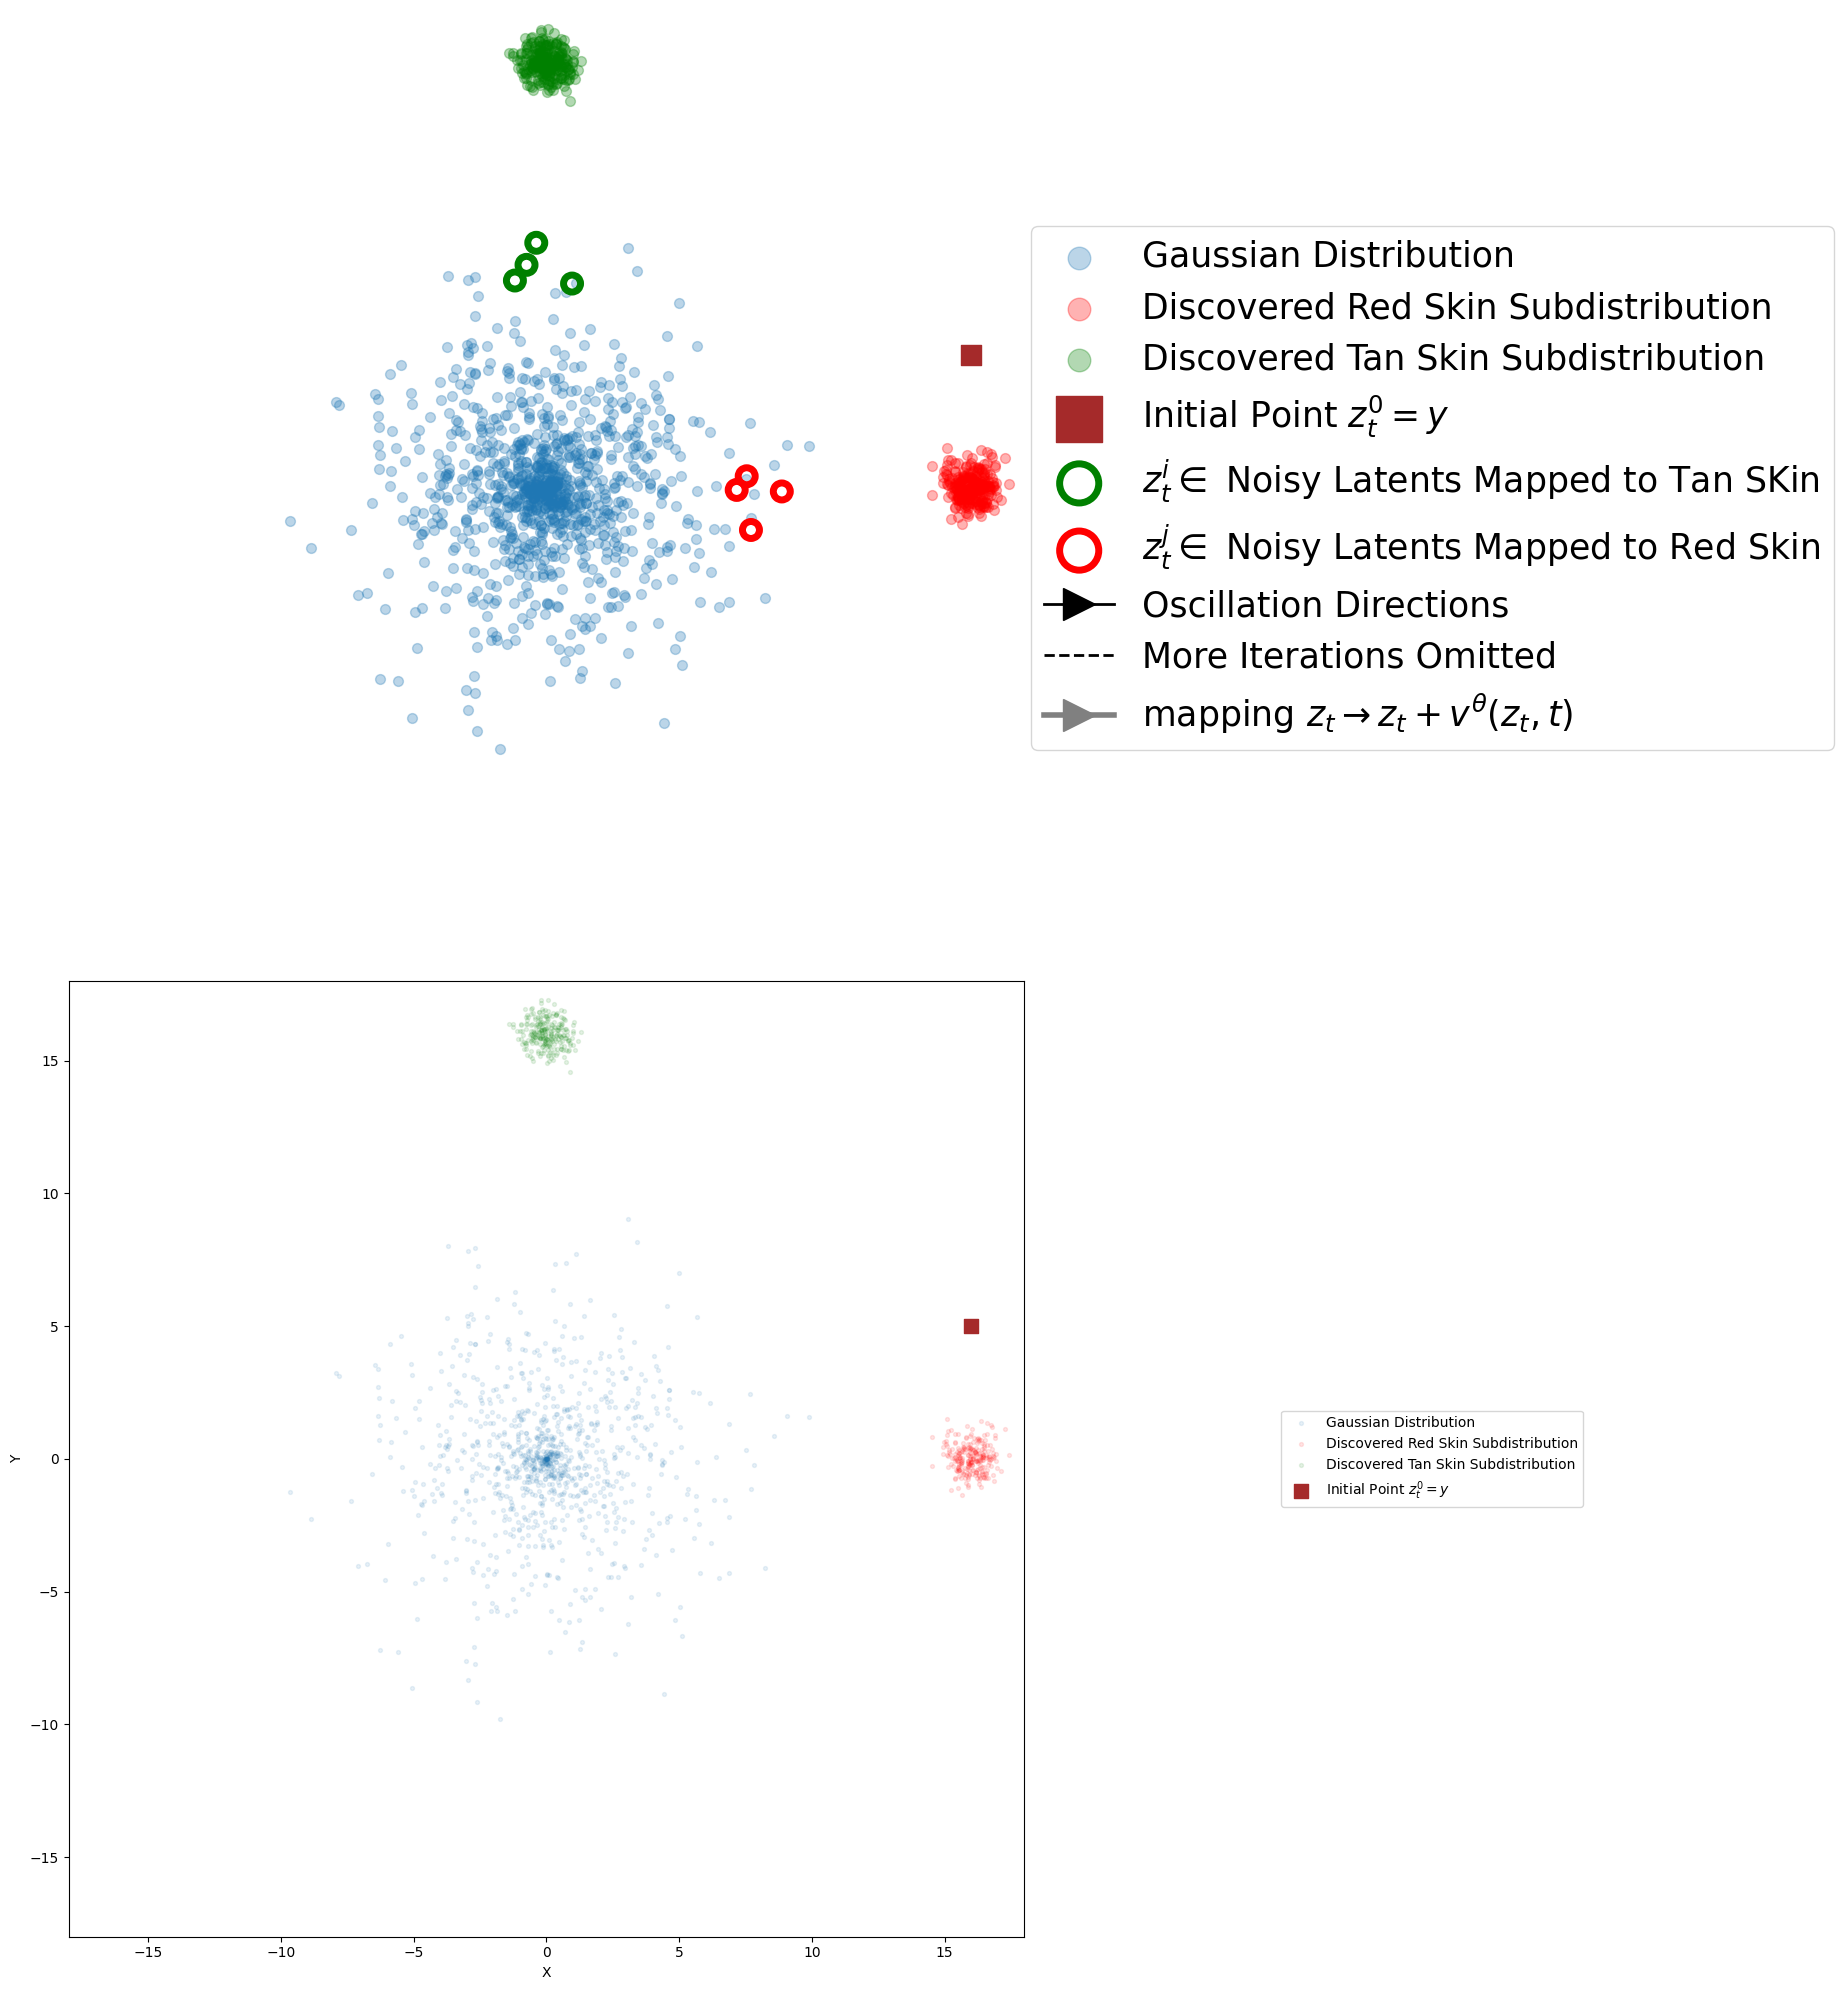

In [8]:

# in the first figure, could you explicitly list the coordinates array of 4 points around 0, 10 and plot them with green cirle empty inside, and  explicitly list the coordinates array of 4 points around 6,0 and plot them with green cirle empty inside 

###### paper plot section 
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import torch
import numpy as np
import torch.nn as nn
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
import torch.nn.functional as F
from matplotlib.lines import Line2D

# Parameters
num_samples = 1000
radius = 2  # Radius of the circle  # 4.0 is good
center = (0, 0)  # Center of the circle
band_width = 3 # Width of the circular band # 3 is good 
gaussian_std = 0.5  # Standard deviation for the Gaussians

# Generate samples on a circular band (samples_0)
theta = torch.linspace(0, 2 * np.pi, num_samples)
r = radius + torch.randn(num_samples) * band_width
x = r * torch.cos(theta)
y = r * torch.sin(theta)
samples_0 = torch.stack((x, y), dim=1)

# Generate 8 means uniformly sampled on a circle of radius 10
num_gaussians = 4
gaussian_radius = 16.0
gaussian_angles = torch.linspace(0, 2 * torch.pi, num_gaussians+1)[:-1]
gaussian_angles = gaussian_angles[[0,1]]
gaussian_means = torch.stack([
    gaussian_radius * torch.cos(gaussian_angles),
    gaussian_radius * torch.sin(gaussian_angles)
], dim=1)

cov = gaussian_std ** 2 * torch.eye(2, dtype=torch.float32)

mvn_list = [MultivariateNormal(mean, cov) for mean in gaussian_means]

samples_per_gaussian = num_samples // num_gaussians
remaining_samples = num_samples % num_gaussians

samples_1 = []
for i, mvn in enumerate(mvn_list):
    if i == 0:
        # Add remaining samples to the first Gaussian
        samples_1.append(mvn.sample((samples_per_gaussian + remaining_samples,)))
    else:
        samples_1.append(mvn.sample((samples_per_gaussian,)))

samples_1 = torch.cat(samples_1, dim=0)

print('Shape of the samples:', samples_0.shape, samples_1.shape)

# Define the coordinates for the points around (0, 10) and (6, 0) with added randomness
np.random.seed(42)  # for reproducibility
random_offset = 1  # maximum random offset

points_around_0_10 = np.array([[-0.5, 9.5-2], [0.5, 9.5-2], [-0.5, 10.5-2], [0.5, 10.5-2]])
points_around_6_0 = np.array([[5.5+2, -2], [6.5+2, -0.5], [4.5+2, 0.5], [7.5+2, 0.5]])

# Add randomness to the points
points_around_0_10 += np.random.uniform(-random_offset, random_offset, size=points_around_0_10.shape)
points_around_6_0 += np.random.uniform(-random_offset, random_offset, size=points_around_6_0.shape)

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20), gridspec_kw={'width_ratios': [1, 0.25], 'height_ratios': [1, 1]})

# First plot without axis
ax1.set_xlim(-gaussian_radius - 2, gaussian_radius + 2)
ax1.set_ylim(-gaussian_radius - 2, gaussian_radius + 2)
ax1.set_aspect('equal', 'box')
ax1.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.3, s = 50,label=r'Gaussian Distribution')

# Split samples_1 into two parts and plot with different colors (flipped)
half = len(samples_1) // 2
ax1.scatter(samples_1[:half, 0].numpy(), samples_1[:half, 1].numpy(), alpha=0.3, s=50, color='red', label=r'Discovered Red Skin Subdistribution')
ax1.scatter(samples_1[half:, 0].numpy(), samples_1[half:, 1].numpy(), alpha=0.3, s= 50, color='green', label=r'Discovered Tan Skin Subdistribution')

ax1.scatter(16, 5, color='brown', s=200, marker='s', label='Initial Point $z^0_t = y$')  # Add brown square at (13,5)

# Plot the points around (0, 10) and (6, 0) with green circles
ax1.scatter(points_around_0_10[:, 0], points_around_0_10[:, 1], facecolors='none', edgecolors='green', s=150, linewidth=5, label='$z_t^i \in$ Noisy Latents Mapped to Tan SKin')
ax1.scatter(points_around_6_0[:, 0], points_around_6_0[:, 1], facecolors='none', edgecolors='red', s=150, linewidth=5, label='$z_t^j \in$ Noisy Latents Mapped to Red Skin')

ax1.set_axis_off()

# Legend for the first plot
ax2.axis('off')
legend_elements = ax1.get_legend_handles_labels()[0]
legend_labels = ax1.get_legend_handles_labels()[1]

# Add black arrow to legend
black_arrow = Line2D([0], [0], color='black', lw=2, marker='>', markersize=10)
legend_elements.append(black_arrow)
legend_labels.append('Oscillation Directions')

# Add dashed black arrow to legend
dashed_black_arrow = Line2D([0], [0], color='black', lw=2, linestyle='--', marker='>', markersize=0.2)
legend_elements.append(dashed_black_arrow)
legend_labels.append('More Iterations Omitted')

# Add thick grey arrow to legend
thick_grey_arrow = Line2D([0], [0], color='grey', lw=4, marker='>', markersize=10, markevery=[-1])
legend_elements.append(thick_grey_arrow)
legend_labels.append(r'mapping $z_t \rightarrow z_t + v^\theta(z_t, t)$')

ax2.legend(
    legend_elements,
    legend_labels,
    loc='center',
    fontsize=25,          # ← 这里
    markerscale=2.3
)
# Print the coordinates of the points
print("Points around (0, 10):")
print(points_around_0_10)
print("\nPoints around (6, 0):")
print(points_around_6_0)


###########################################################################################
# Second plot with axis
ax3.set_xlim(-gaussian_radius - 2, gaussian_radius + 2)
ax3.set_ylim(-gaussian_radius - 2, gaussian_radius + 2)
ax3.set_aspect('equal', 'box')
ax3.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.1, s=8, label=r'Gaussian Distribution')

# Split samples_1 into two parts and plot with different colors (flipped)
ax3.scatter(samples_1[:half, 0].numpy(), samples_1[:half, 1].numpy(), alpha=0.1, s=8, color='red', label=r'Discovered Red Skin Subdistribution')
ax3.scatter(samples_1[half:, 0].numpy(), samples_1[half:, 1].numpy(), alpha=0.1, s=8, color='green', label=r'Discovered Tan Skin Subdistribution')

ax3.scatter(16, 5, color='brown', s=100, marker='s', label='Initial Point $z^0_t = y$')  # Add brown square at (13,5)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')

# Legend for the second plot
ax4.axis('off')
ax4.legend(*ax3.get_legend_handles_labels(), loc='center')

plt.tight_layout()
plt.show()  # Ensure you display the plot


Shape of the samples: torch.Size([100000, 2]) torch.Size([100000, 2])


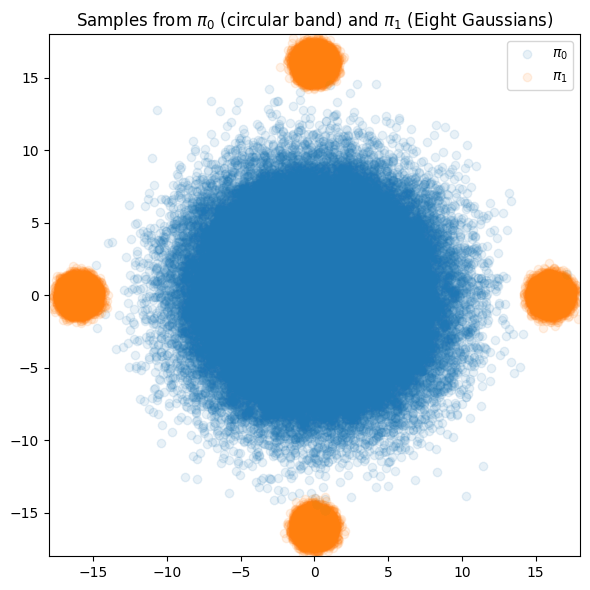

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import torch
import numpy as np
import torch.nn as nn
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Parameters
num_samples = 100000
radius = 4  # Radius of the circle  # 4.0 is good
center = (0, 0)  # Center of the circle
band_width = 3 # Width of the circular band # 3 is good 
gaussian_std = 0.5  # Standard deviation for the Gaussians

# Generate samples on a circular band (samples_0)
theta = torch.linspace(0, 2 * np.pi, num_samples)
r = radius + torch.randn(num_samples) * band_width
x = r * torch.cos(theta)
y = r * torch.sin(theta)
samples_0 = torch.stack((x, y), dim=1)

# Generate 8 means uniformly sampled on a circle of radius 10
num_gaussians = 4
gaussian_radius = 16.0
gaussian_angles = torch.linspace(0, 2 * torch.pi, num_gaussians+1)[:-1]
gaussian_means = torch.stack([
    gaussian_radius * torch.cos(gaussian_angles),
    gaussian_radius * torch.sin(gaussian_angles)
], dim=1)

cov = gaussian_std ** 2 * torch.eye(2, dtype=torch.float32)

mvn_list = [MultivariateNormal(mean, cov) for mean in gaussian_means]

samples_per_gaussian = num_samples // num_gaussians
remaining_samples = num_samples % num_gaussians

samples_1 = []
for i, mvn in enumerate(mvn_list):
    if i == 0:
        # Add remaining samples to the first Gaussian
        samples_1.append(mvn.sample((samples_per_gaussian + remaining_samples,)))
    else:
        samples_1.append(mvn.sample((samples_per_gaussian,)))

samples_1 = torch.cat(samples_1, dim=0)

print('Shape of the samples:', samples_0.shape, samples_1.shape)

# Plotting
plt.figure(figsize=(6, 6))
plt.xlim(-gaussian_radius - 2, gaussian_radius + 2)
plt.ylim(-gaussian_radius - 2, gaussian_radius + 2)
plt.title(r'Samples from $\pi_0$ (circular band) and $\pi_1$ (Eight Gaussians)')
plt.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.1, label=r'$\pi_0$')
plt.scatter(samples_1[:, 0].numpy(), samples_1[:, 1].numpy(), alpha=0.1, label=r'$\pi_1$')
plt.legend()

plt.tight_layout()
plt.show()  # Ensure you display the plot


Shape of the samples: torch.Size([100000, 2]) torch.Size([100000, 2])


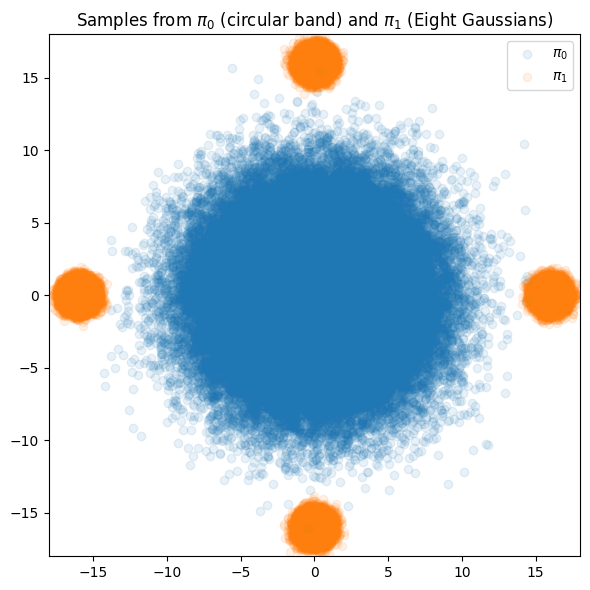

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import torch
import numpy as np
import torch.nn as nn
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Parameters
num_samples = 100000
radius = 4  # Radius of the circle  # 4.0 is good
center = (0, 0)  # Center of the circle
band_width = 3 # Width of the circular band # 3 is good 
gaussian_std = 0.5  # Standard deviation for the Gaussians

# Generate samples on a circular band (samples_0)
theta = torch.linspace(0, 2 * np.pi, num_samples)
r = radius + torch.randn(num_samples) * band_width
x = r * torch.cos(theta)
y = r * torch.sin(theta)
samples_0 = torch.stack((x, y), dim=1)

# Generate 8 means uniformly sampled on a circle of radius 10
num_gaussians = 4
gaussian_radius = 16.0
gaussian_angles = torch.linspace(0, 2 * torch.pi, num_gaussians+1)[:-1]
gaussian_means = torch.stack([
    gaussian_radius * torch.cos(gaussian_angles),
    gaussian_radius * torch.sin(gaussian_angles)
], dim=1)

cov = gaussian_std ** 2 * torch.eye(2, dtype=torch.float32)

mvn_list = [MultivariateNormal(mean, cov) for mean in gaussian_means]

samples_per_gaussian = num_samples // num_gaussians
remaining_samples = num_samples % num_gaussians

samples_1 = []
for i, mvn in enumerate(mvn_list):
    if i == 0:
        # Add remaining samples to the first Gaussian
        samples_1.append(mvn.sample((samples_per_gaussian + remaining_samples,)))
    else:
        samples_1.append(mvn.sample((samples_per_gaussian,)))

samples_1 = torch.cat(samples_1, dim=0)

print('Shape of the samples:', samples_0.shape, samples_1.shape)

# Plotting
plt.figure(figsize=(6, 6))
plt.xlim(-gaussian_radius - 2, gaussian_radius + 2)
plt.ylim(-gaussian_radius - 2, gaussian_radius + 2)
plt.title(r'Samples from $\pi_0$ (circular band) and $\pi_1$ (Eight Gaussians)')
plt.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.1, label=r'$\pi_0$')
plt.scatter(samples_1[:, 0].numpy(), samples_1[:, 1].numpy(), alpha=0.1, label=r'$\pi_1$')
plt.legend()

plt.tight_layout()
plt.show()  # Ensure you display the plot


In [7]:
print(gaussian_angles[:-1])

tensor([0.0000, 1.5708, 3.1416])


In [8]:
# import torch
# import numpy as np
# import torch.nn as nn
# from torch.distributions import Normal, Categorical
# from torch.distributions.multivariate_normal import MultivariateNormal
# from torch.distributions.mixture_same_family import MixtureSameFamily
# import matplotlib.pyplot as plt
# import torch.nn.functional as F

# # Parameters
# num_samples = 10000
# radius = 5.0  # Radius of the circle
# center = (0, 0)  # Center of the circle
# band_width = 0.5  # Width of the circular band
# gaussian_std = 0.3  # Standard deviation for the Gaussians

# # Generate samples on a circular band (samples_0)
# theta = torch.linspace(0, 2*np.pi, num_samples)
# r = radius + torch.randn(num_samples) * band_width
# x = r * torch.cos(theta)
# y = r * torch.sin(theta)
# samples_0 = torch.stack((x, y), dim=1)

# # Generate samples from two small Gaussian distributions (samples_1)
# mean1 = torch.tensor([1, 1], dtype=torch.float32)
# mean2 = torch.tensor([-4, -4], dtype=torch.float32)
# cov = gaussian_std**2 * torch.eye(2, dtype=torch.float32)

# mvn1 = MultivariateNormal(mean1, cov)
# mvn2 = MultivariateNormal(mean2, cov)

# samples_1_1 = mvn1.sample((5000,))
# samples_1_2 = mvn2.sample((5000,))
# samples_1 = torch.cat([samples_1_1, samples_1_2], dim=0)

# print('Shape of the samples:', samples_0.shape, samples_1.shape)

# plt.figure(figsize=(4,4))
# plt.xlim(-radius-2, radius+2)
# plt.ylim(-radius-2, radius+2)
# plt.title(r'Samples from $\pi_0$ (circular band) and $\pi_1$ (Two Gaussians)')
# plt.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.1, label=r'$\pi_0$')
# plt.scatter(samples_1[:, 0].numpy(), samples_1[:, 1].numpy(), alpha=0.1, label=r'$\pi_1$')
# plt.legend()

# plt.tight_layout()

In [9]:
# import torch
# import numpy as np
# import torch.nn as nn
# from torch.distributions import Normal, Categorical
# from torch.distributions.multivariate_normal import MultivariateNormal
# from torch.distributions.mixture_same_family import MixtureSameFamily
# import matplotlib.pyplot as plt
# import torch.nn.functional as F

# # Parameters
# num_samples = 10000
# band_width = 0.5  # Width of the vertical bands
# gaussian_std = 0.3  # Standard deviation for the Gaussians

# # Generate samples for the left vertical band (samples_0)
# x_0 = torch.ones(num_samples) * (-2)  # x-coordinate fixed at -2
# y_0 = torch.randn(num_samples) * band_width
# samples_0 = torch.stack((x_0, y_0), dim=1)

# # Generate samples for the right vertical band (samples_1)
# x_1 = torch.ones(num_samples) * 2  # x-coordinate fixed at 2
# y_1 = torch.randn(num_samples) * band_width
# samples_1 = torch.stack((x_1, y_1), dim=1)

# print('Shape of the samples:', samples_0.shape, samples_1.shape)

# plt.figure(figsize=(4,4))
# plt.xlim(-4, 4)
# plt.ylim(-4, 4)
# plt.title(r'Samples from $\pi_0$ (left band) and $\pi_1$ (right band)')
# plt.scatter(samples_0[:, 0].numpy(), samples_0[:, 1].numpy(), alpha=0.1, label=r'$\pi_0$')
# plt.scatter(samples_1[:, 0].numpy(), samples_1[:, 1].numpy(), alpha=0.1, label=r'$\pi_1$')
# plt.legend()

# plt.tight_layout()

In [10]:
print(samples_0.shape)

torch.Size([100000, 2])


## Define the Flow Model
Given empirical observations of $X_0\sim \pi_0$ and $X_1\sim \pi_1$,
the rectified flow induced from $(X_0,X_1)$
is an ordinary differentiable model (ODE)
on time $t\in[0,1]$,
$$
d Z_t = v^X(Z_t, t) d t,
$$
which $v$ is set in a way that ensures that $Z_1$ follows $\pi_1$ when $Z_0 \sim \pi_0$. Let $X_t = t X_1 + (1-t)X_0$ be the linear interpolation of $X_0$ and $X_1$. Then $v$ is given by
$$
v^X(z,t) = \mathbb{E}[X_1 - X_0 ~|~ X_t = z  ] =  \arg\min_{v} \int_0^1 \mathbb{E}[|| X_1-X_0 - v(X_t,t) ||^2] \mathrm{d} t,
$$
where the (conditional) expectation is w.r.t. the joint distribution of $(X_0,X_1)$.

We parameterize $v^X(z,t)$ with a 3-layer neural network.

In [11]:
# class MLP(nn.Module):
#     def __init__(self, input_dim=2, hidden_num=100, num_heads=4):
#         super().__init__()
#         self.input_dim = input_dim
#         self.hidden_num = hidden_num
#         self.num_heads = num_heads

#         self.fc1 = nn.Linear(input_dim+1, hidden_num, bias=True)
#         self.attention = nn.MultiheadAttention(hidden_num, num_heads)
#         self.fc2 = nn.Linear(hidden_num, hidden_num, bias=True)
#         self.fc3 = nn.Linear(hidden_num, input_dim, bias=True)
#         self.act = nn.GELU()

#     def forward(self, x_input, t):
#         inputs = torch.cat([x_input, t], dim=1)
#         x = self.fc1(inputs)
#         x = self.act(x)

#         # Reshape for attention
#         x = x.unsqueeze(0)  # Add sequence dimension
#         x, _ = self.attention(x, x, x)
#         x = x.squeeze(0)  # Remove sequence dimension

#         x = self.fc2(x)
#         x = self.act(x)
#         x = self.fc3(x)

#         return x

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_num=100):
        super().__init__()
        self.fc1 = nn.Linear(input_dim+1, hidden_num, bias=True)
        self.fc2 = nn.Linear(hidden_num, hidden_num, bias=True)
        self.fc3 = nn.Linear(hidden_num, input_dim, bias=True)
        self.act = lambda x: torch.tanh(x)

    def forward(self, x_input, t):
        inputs = torch.cat([x_input, t], dim=1)
        x = self.fc1(inputs)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)

        return x

Then we define the rectfied flow class.

In [4]:
class RectifiedFlow():
  def __init__(self, model=None, num_steps=1000):
    self.model = model
    self.N = num_steps

  def get_train_tuple(self, z0=None, z1=None):
    t = torch.rand((z1.shape[0], 1)).to("cuda")
    z_t =  t * z1 + (1.-t) * z0
    target = z1 - z0

    return z_t, t, target

  @torch.no_grad()
  def sample_ode(self, z0=None, N=None):
    ### NOTE: Use Euler method to sample from the learned flow
    if N is None:
      N = self.N
    dt = 1./N
    traj = [] # to store the trajectory
    z = z0.detach().clone()
    batchsize = z.shape[0]

    z = z.to("cuda")
    traj.append(z.detach().clone())
    for i in range(N):
      t = torch.ones((batchsize,1)) * i / N
      t = t.to("cuda")
      z = z.to("cuda")
      pred = self.model(z, t)
      z = z.detach().clone() + pred * dt

      traj.append(z.detach().clone())

    return traj

## Define the training method and other misc. code
We define the training method here. The loss function is:
$$
\min_{\theta}
\int_0^1 E_{X_0 \sim \pi_0, X_1 \sim \pi_1} \left [ {||( X_1 - X_0) - v_\theta\big (X_t,~ t\big)||}^2
\right ] \text{d}t,
~~~~~\text{with}~~~~
X_t = t X_1 + (1-t) X_0.
$$

In [5]:
def train_rectified_flow(rectified_flow, optimizer, pairs, batchsize, inner_iters):
  loss_curve = []
  for i in range(inner_iters+1):
    optimizer.zero_grad()
    indices = torch.randperm(len(pairs))[:batchsize]
    batch = pairs[indices] #     # print(batch.shape) torch.Size([2048, 2, 2])
    z0 = batch[:, 0].detach().clone()  #     # print(z0.shape) torch.Size([2048, 2])
    z1 = batch[:, 1].detach().clone()  #     # print(z1.shape) torch.Size([2048, 2])
    z_t, t, target = rectified_flow.get_train_tuple(z0=z0, z1=z1)

    pred = rectified_flow.model(z_t, t)
    loss = (target - pred).view(pred.shape[0], -1).abs().pow(2).sum(dim=1)
    loss = loss.mean()
    loss.backward()

    optimizer.step()
    loss_curve.append(np.log(loss.item())) ## to store the loss curve

  return rectified_flow, loss_curve


Misc. code for plotting figures.

In [6]:
@torch.no_grad()
def draw_plot(rectified_flow, z0, z1, N=None):
  traj = rectified_flow.sample_ode(z0=z0, N=N)

  plt.figure(figsize=(4,4))
  plt.xlim(-M,M)
  plt.ylim(-M,M)

  plt.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(), label=r'$\pi_1$', alpha=0.15)
  plt.scatter(traj[0][:, 0].cpu().numpy(), traj[0][:, 1].cpu().numpy(), label=r'$\pi_0$', alpha=0.15)
  plt.scatter(traj[-1][:, 0].cpu().numpy(), traj[-1][:, 1].cpu().numpy(), label='Generated', alpha=0.15)
  plt.legend()
  plt.title('Distribution')
  plt.tight_layout()

  traj_particles = torch.stack(traj)
  plt.figure(figsize=(4,4))
  plt.xlim(-M,M)
  plt.ylim(-M,M)
  plt.axis('equal')
  for i in range(30):
    plt.plot(traj_particles[:, i, 0].cpu().numpy(), traj_particles[:, i, 1].cpu().numpy())
  plt.title('Transport Trajectory')
  plt.tight_layout()

## 1-Rectified Flow
We start by generating the pairs $(X_0, X_1)$ by pooling randomly sampled points from ```sample_0``` and ```sample_1```. So $(X_0,X_1)$ forms an independent coupling of $\pi_0$ and $\pi_1$.


In [7]:
x_0 = samples_0.detach().clone()[torch.randperm(len(samples_0))].to("cuda")
x_1 = samples_1.detach().clone()[torch.randperm(len(samples_1))].to("cuda")
x_pairs = torch.stack([x_0, x_1], dim=1)
print(x_pairs.shape)

torch.Size([100000, 2, 2])


We create ```rectified_flow_1``` and its corresponding ```optimizer``` and traing 1-Rectified Flow with ```train_rectified_flow``` using $(X_0, X_1)$ above.

Text(0.5, 1.0, 'Training Loss Curve')

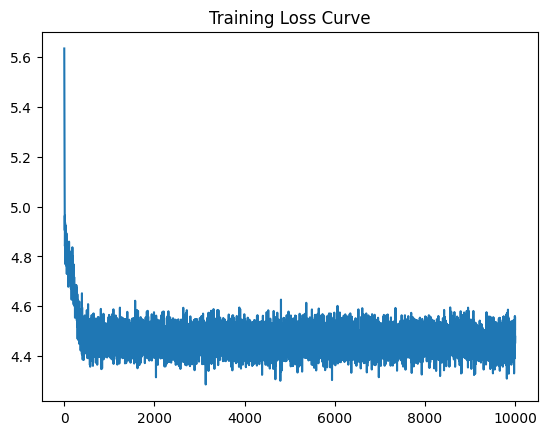

In [8]:
iterations = 10000
batchsize = 2048
input_dim = 2


x_pairs = x_pairs.to("cuda")
rectified_flow_1 = RectifiedFlow(model=MLP(input_dim, hidden_num=100).to("cuda"), num_steps=100)
optimizer = torch.optim.Adam(rectified_flow_1.model.parameters(), lr=5e-3)

rectified_flow_1, loss_curve = train_rectified_flow(rectified_flow_1, optimizer, x_pairs, batchsize, iterations)
plt.plot(np.linspace(0, iterations, iterations+1), loss_curve[:(iterations+1)])
plt.title('Training Loss Curve')

# fixed point test

torch.Size([100000, 2, 2])
Shape of z1: torch.Size([100000, 2])
Shape of zk: torch.Size([20000, 2])
torch.Size([1, 2])
tensor([[1.]], device='cuda:0')
tensor([[0.9900]], device='cuda:0')
tensor([[0.9800]], device='cuda:0')
tensor([[0.9700]], device='cuda:0')
tensor([[0.9600]], device='cuda:0')
tensor([[0.9500]], device='cuda:0')
tensor([[0.9400]], device='cuda:0')
tensor([[0.9300]], device='cuda:0')
tensor([[0.9200]], device='cuda:0')
tensor([[0.9100]], device='cuda:0')
tensor([[0.9000]], device='cuda:0')
tensor([[0.8900]], device='cuda:0')
tensor([[0.8800]], device='cuda:0')
tensor([[0.8700]], device='cuda:0')
tensor([[0.8600]], device='cuda:0')
tensor([[0.8500]], device='cuda:0')
tensor([[0.8400]], device='cuda:0')
tensor([[0.8300]], device='cuda:0')
tensor([[0.8200]], device='cuda:0')
tensor([[0.8100]], device='cuda:0')
tensor([[0.8000]], device='cuda:0')
tensor([[0.7900]], device='cuda:0')
tensor([[0.7800]], device='cuda:0')
tensor([[0.7700]], device='cuda:0')
tensor([[0.7600]], de

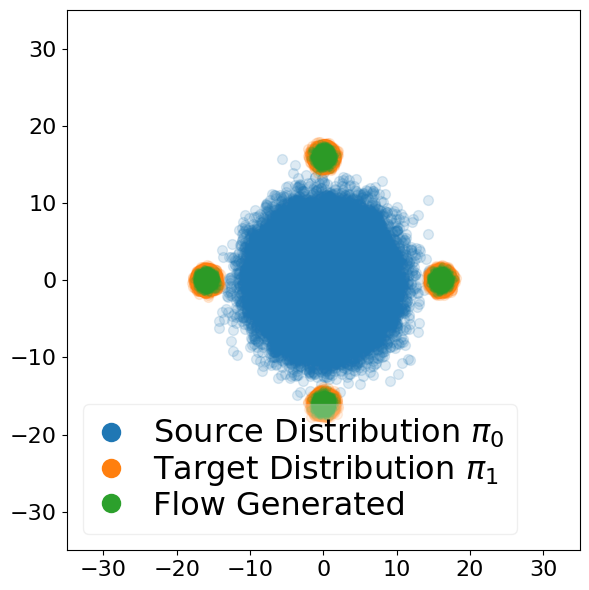

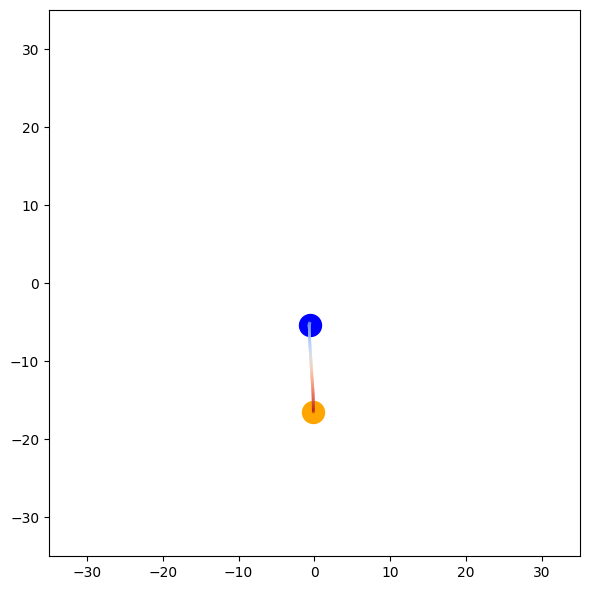

/tmp/ipykernel_579919/2108396834.py:198: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


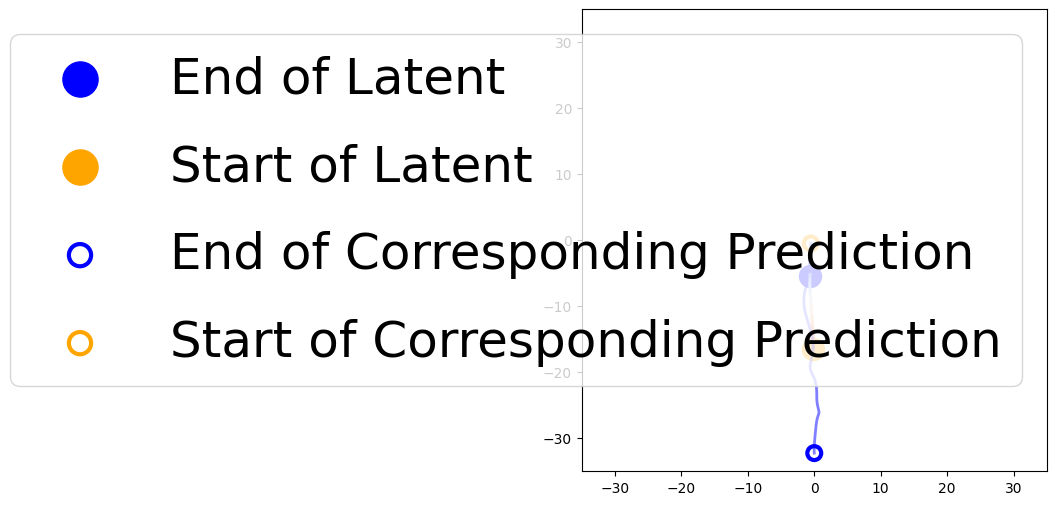

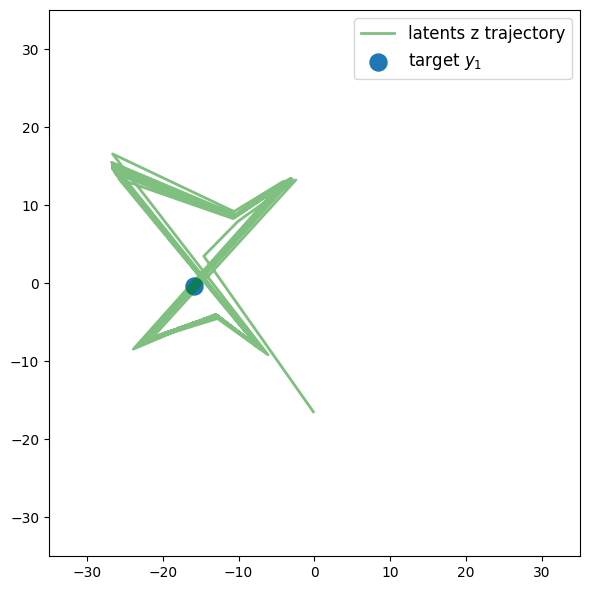

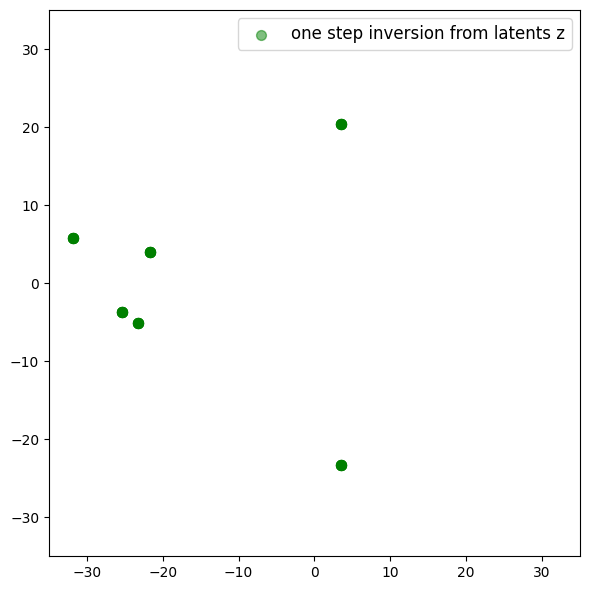

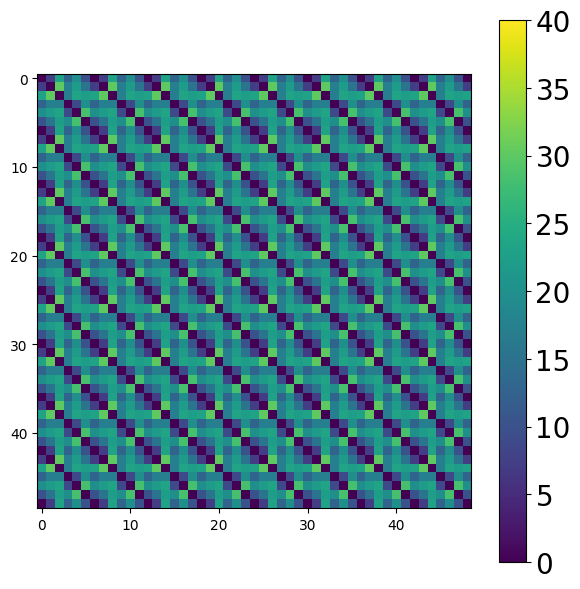

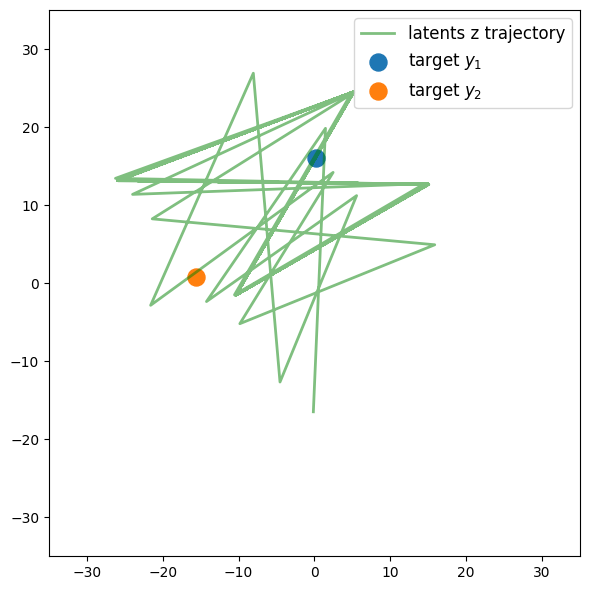

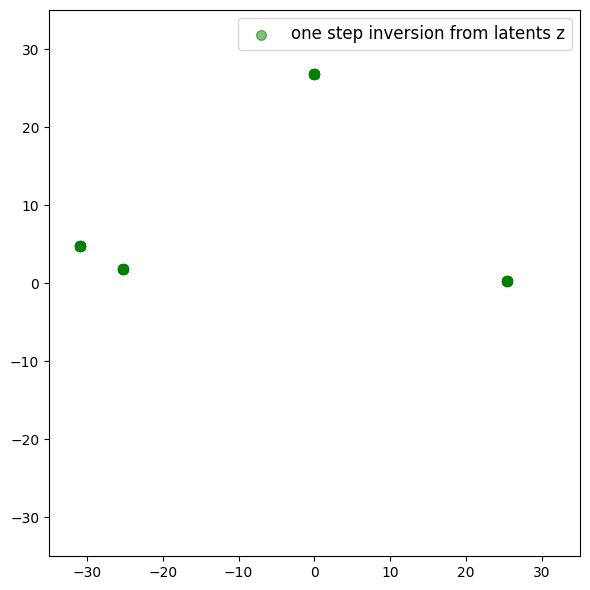

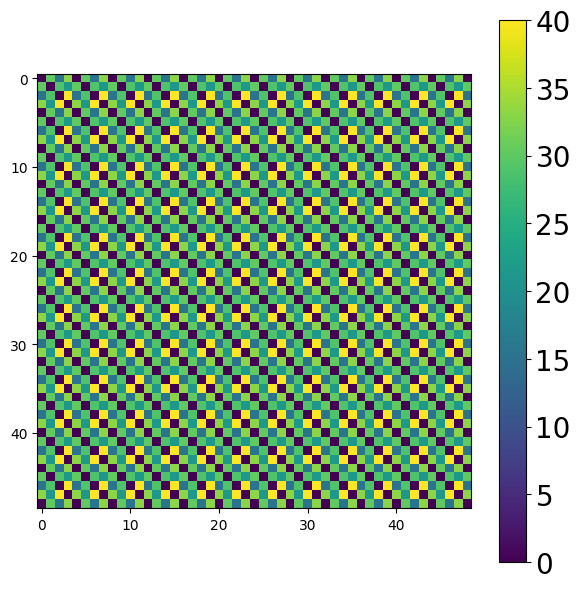

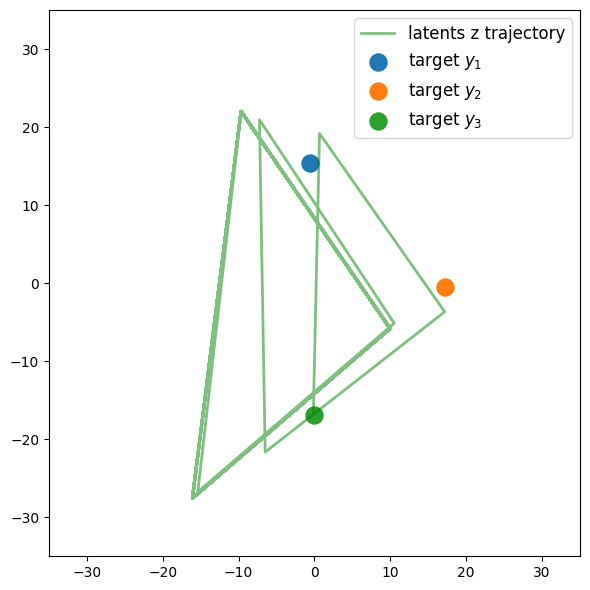

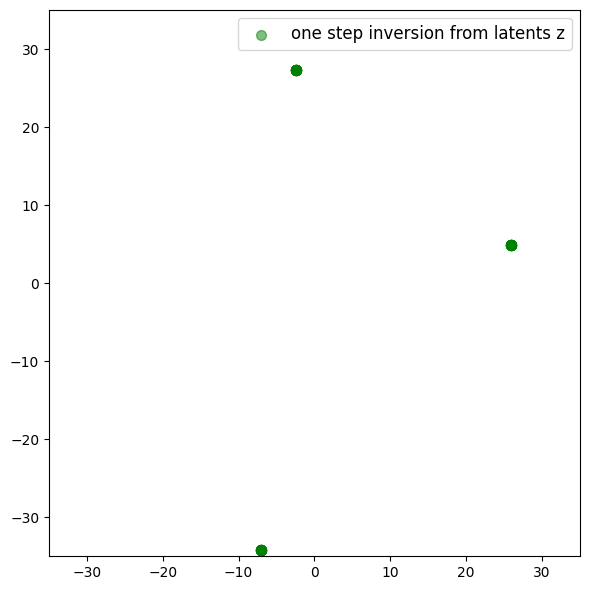

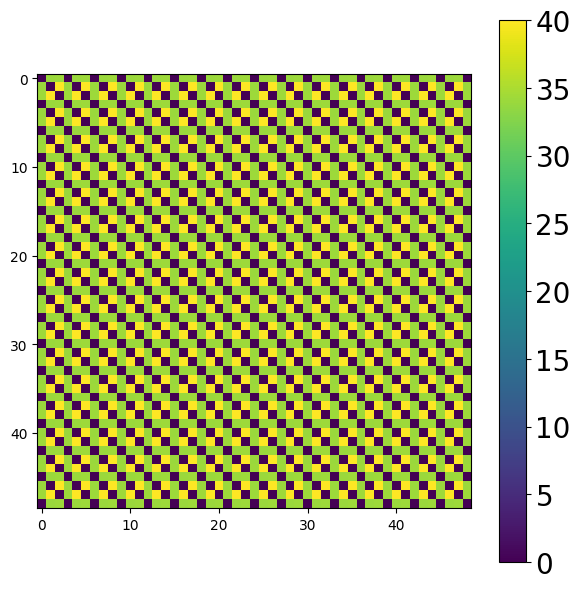

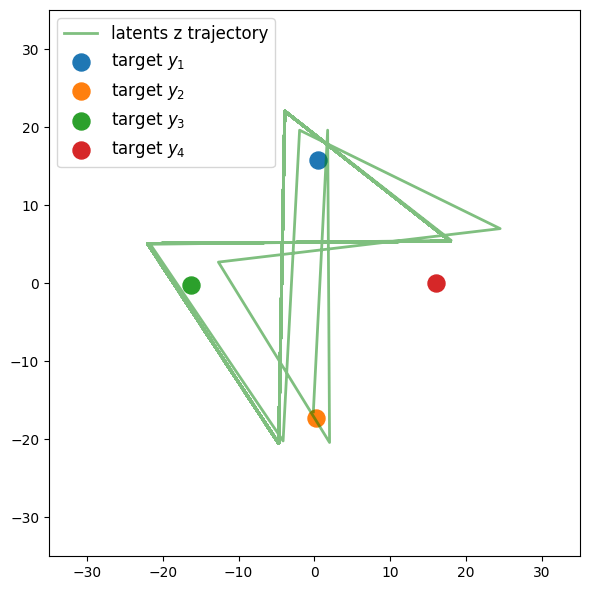

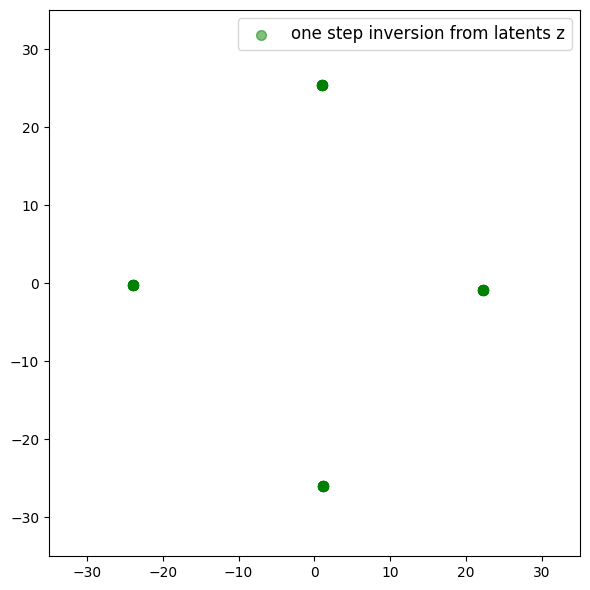

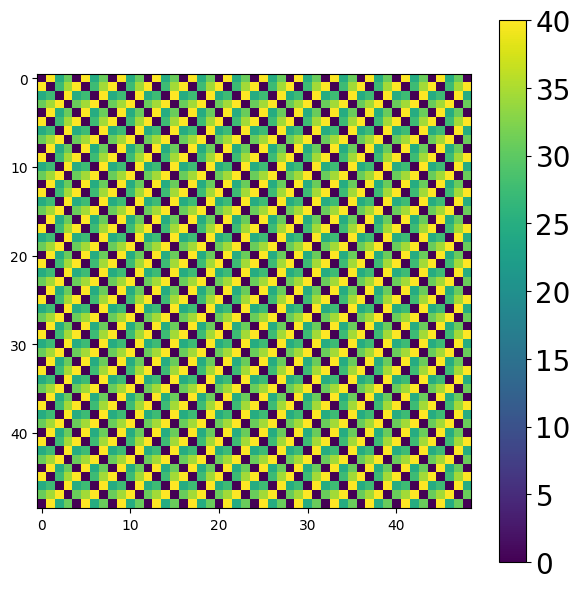

In [31]:
# seed 22 is good enough, seed 3 also good
seed = 666
inv_scale = 0.6

torch.manual_seed(seed)


x_0 = samples_0.detach().clone()[torch.randperm(len(samples_0))]
x_1 = samples_1.detach().clone()[torch.randperm(len(samples_1))]
x_pairs = torch.stack([x_0, x_1], dim=1)
print(x_pairs.shape)


################# parameter input
z0 = x_0
z1 = x_1
# Randomly select half of the points from z1
num_points = z1.shape[0]
half_points = num_points // 5
random_indices = torch.randperm(num_points)[:half_points]
zk = z1[random_indices].clone()

print(f"Shape of z1: {z1.shape}")
print(f"Shape of zk: {zk.shape}")

N = 100    # N is for timestep
M = 35
#################


################ # first sample a path
#  pred = rectified_flow.model(z_t, t) # print(z_t.shape) torch.Size([2048, 2]) # print(t.shape) torch.Size([2048, 1])
# Set the random seed for reproducibility
# Sample a single point from x_0
sampled_point = x_0[torch.randint(0, x_0.size(0), (1,))].to("cuda")
print(sampled_point.shape)
batchsize = sampled_point.shape[0]


dt = 1./N
traj = [] # to store the trajectory
z = sampled_point
traj.append(z.detach().clone())
for i in range(N):
  t = torch.ones((batchsize,1)) * i / N
  t = t.to("cuda")
  pred = rectified_flow_1.model(z, t)
  z = z.detach().clone() + pred * dt
  traj.append(z.detach().clone())

traj_single = traj


################ # inversion   # ? + model(?) = z
NN = 100
dtt = 1./NN
traj = [] # to store the trajectory
inv_history = []

z = traj_single[-1]
traj.append(z.detach().clone())
for i in range(NN):
  t = torch.ones((batchsize,1)) * i / NN
  t = t.to("cuda")
  t = 1-t
  print(t)
  pred = rectified_flow_1.model(z, t)


  inv_z = z.detach().clone() + pred 
  inv_history.append(inv_z.detach().clone())
  
  z = z.detach().clone() - pred * dtt
  traj.append(z.detach().clone())

traj_inversion = inv_history 


###################################################################################################
# Distribution plot
plt.figure(figsize=(6, 6))
plt.xlim(-M, M)
plt.ylim(-M, M)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.scatter(z0[:, 0].cpu().numpy(), z0[:, 1].cpu().numpy(), label=r'Source Distribution $\pi_0$', alpha=0.15, s=50)
plt.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(), label=r'Target Distribution $\pi_1$', alpha=0.15, s=50)
plt.scatter(zk[:, 0].cpu().numpy(), zk[:, 1].cpu().numpy(), label='Flow Generated', alpha=0.15, s=15)



# leg = plt.legend(
#     fontsize=20,
#     markerscale=1.6,
#     handlelength=2.0,
#     labelspacing=0.2
# )

# for artist in leg.get_children():
#     if hasattr(artist, "set_alpha"):
#         artist.set_alpha(0.4)


from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='#1f77b4',  # blue
        markeredgecolor='none',     # ❗ no black outline
        markersize=14               # ❗ bigger dot
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='#ff7f0e',  # orange
        markeredgecolor='none',
        markersize=14
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='#2ca02c',  # green
        markeredgecolor='none',
        markersize=14
    ),
]


plt.legend(
    legend_elements,
    [
        r'Source Distribution $\pi_0$',
        r'Target Distribution $\pi_1$',
        'Flow Generated'
    ],
    fontsize=23,
    handlelength=1.0,
    labelspacing=0.08,
    frameon=True,
    framealpha=0.3    # ← transparency of legend box
)





plt.tight_layout()
plt.show()

# Single Trajectory plot
plt.figure(figsize=(6, 6))
plt.xlim(-M, M)
plt.ylim(-M, M)

traj_array = torch.stack(traj_single).squeeze().cpu().numpy()
colors = plt.cm.coolwarm(np.linspace(0, 1, len(traj_array)))
for i in range(len(traj_array) - 1):
    plt.plot(traj_array[i:i+2, 0], traj_array[i:i+2, 1], color=colors[i], alpha=0.5, linewidth=2)
plt.scatter(traj_array[0, 0], traj_array[0, 1], color='blue', label='Start', s=250)
plt.scatter(traj_array[-1, 0], traj_array[-1, 1], color='orange', label='End', s=250)



plt.tight_layout()
plt.show()

# Inversion Trajectory plot
plt.figure(figsize=(6, 6))
plt.xlim(-M, M)
plt.ylim(-M, M)

traj_array = torch.stack(traj_single).squeeze().cpu().numpy()
colors = plt.cm.coolwarm(np.linspace(0, 1, len(traj_array)))
for i in range(len(traj_array) - 1):
    plt.plot(traj_array[i:i+2, 0], traj_array[i:i+2, 1], color=colors[i], alpha=0.5, linewidth=2)
plt.scatter(traj_array[0, 0], traj_array[0, 1], color='blue', label='End of Latent', s=250)
plt.scatter(traj_array[-1, 0], traj_array[-1, 1], color='orange', label='Start of Latent', s=250)

traj_inversion_array = torch.stack(traj_inversion).squeeze().cpu().numpy()
plt.plot(traj_inversion_array[:, 0], traj_inversion_array[:, 1], 'b-', alpha=0.5, linewidth=2)
plt.scatter(traj_inversion_array[0, 0], traj_inversion_array[0, 1], facecolors='none', edgecolors='blue', label='End of Corresponding Prediction', s=100, linewidth=3)
plt.scatter(traj_inversion_array[-1, 0], traj_inversion_array[-1, 1], facecolors='none', edgecolors='orange', label='Start of Corresponding Prediction', s=100, linewidth=3)

plt.legend(
    fontsize=36,        # text size
    markerscale=1.6,    # legend marker size
    handlelength=2.0,
    labelspacing=0.8
)


plt.tight_layout()
plt.show()

# Fixed point plots
num_experiments = len(mvn_list)

for experiment in range(1, num_experiments + 1):
    traj = []  # to store the trajectory
    predict_history = []

    z = traj_single[-1]
    
    # Randomly select 'experiment' number of distributions from mvn_list
    mvn_indices = torch.randperm(len(mvn_list))[:experiment]
    selected_mvns = [mvn_list[i] for i in mvn_indices]

    # Sample one point from each selected distribution
    targets = [mvn.sample((1,)).to('cuda') for mvn in selected_mvns]
    
    z_target = torch.clone(traj_single[-1]).detach()

    traj.append(z.detach().clone())
    for i in range(300):
        t = inv_scale*torch.ones((batchsize,1)) 
        t = t.to("cuda")
        pred = rectified_flow_1.model(z, t)
        
        predict_z = z.detach().clone() + pred 
        predict_history.append(predict_z.detach().clone())

        for j in range(experiment):
            if i % experiment == j:
                z_target = targets[j]

        z = z_target - pred 
        traj.append(z.detach().clone())

    # Trajectory of Latents plot
    plt.figure(figsize=(6, 6))
    plt.xlim(-M, M)
    plt.ylim(-M, M)

    traj_fixedpoint_array = torch.stack(traj).squeeze().cpu().numpy()
    plt.plot(traj_fixedpoint_array[:, 0], traj_fixedpoint_array[:, 1], 'g-', alpha=0.5, linewidth=2, label='latents z trajectory')
    
    for j, target in enumerate(targets):
        target_array = target.cpu().numpy()
        plt.scatter(target_array[:, 0], target_array[:, 1], c=f'C{j}', s=150, label=f'target $y_{j+1}$')
    
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Trajectory of Predicts plot
    plt.figure(figsize=(6, 6))
    plt.xlim(-M, M)
    plt.ylim(-M, M)
    predict_history_array = torch.stack(predict_history).squeeze().cpu().numpy()
    last_100_points = predict_history_array[-50:] if len(predict_history_array) > 50 else predict_history_array
    plt.scatter(last_100_points[:, 0], last_100_points[:, 1], c='g', alpha=0.5, s=50, label='one step inversion from latents z')
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Pairwise distances heatmap
    plt.figure(figsize=(6, 6))
    V_history = traj
    N = len(V_history)
    norms = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
                norms[i,j] = torch.linalg.norm(V_history[i] - V_history[j])
    im = plt.imshow(norms[-50:-1, -50:-1], cmap='viridis', interpolation='nearest', vmin=0, vmax=40)
    cbar = plt.colorbar(im)
    cbar.ax.tick_params(labelsize=20)
    plt.tight_layout()
    plt.show()


torch.Size([100000, 2, 2])
Shape of z1: torch.Size([100000, 2])
Shape of zk: torch.Size([20000, 2])
torch.Size([1, 2])
tensor([[1.]], device='cuda:0')
tensor([[0.9900]], device='cuda:0')
tensor([[0.9800]], device='cuda:0')
tensor([[0.9700]], device='cuda:0')
tensor([[0.9600]], device='cuda:0')
tensor([[0.9500]], device='cuda:0')
tensor([[0.9400]], device='cuda:0')
tensor([[0.9300]], device='cuda:0')
tensor([[0.9200]], device='cuda:0')
tensor([[0.9100]], device='cuda:0')
tensor([[0.9000]], device='cuda:0')
tensor([[0.8900]], device='cuda:0')
tensor([[0.8800]], device='cuda:0')
tensor([[0.8700]], device='cuda:0')
tensor([[0.8600]], device='cuda:0')
tensor([[0.8500]], device='cuda:0')
tensor([[0.8400]], device='cuda:0')
tensor([[0.8300]], device='cuda:0')
tensor([[0.8200]], device='cuda:0')
tensor([[0.8100]], device='cuda:0')
tensor([[0.8000]], device='cuda:0')
tensor([[0.7900]], device='cuda:0')
tensor([[0.7800]], device='cuda:0')
tensor([[0.7700]], device='cuda:0')
tensor([[0.7600]], de

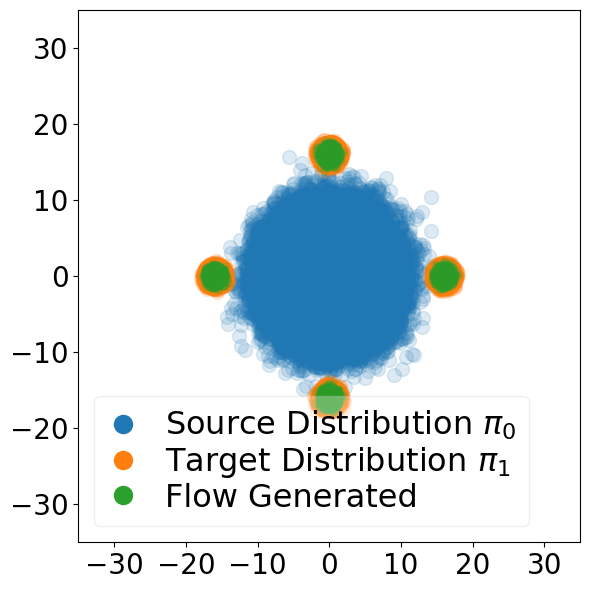

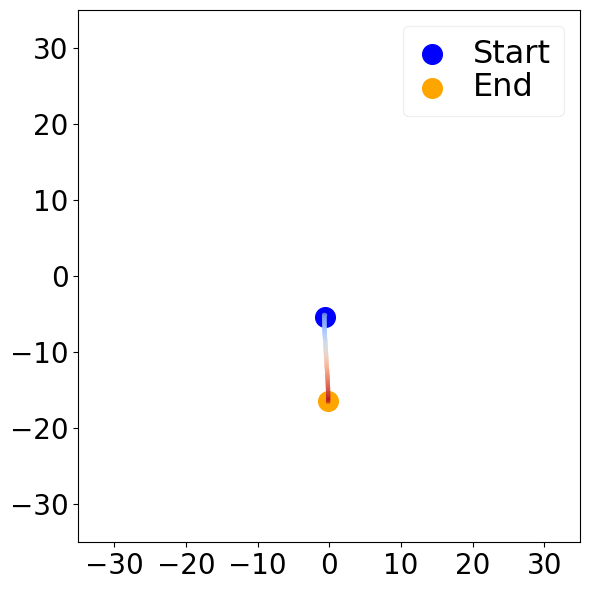

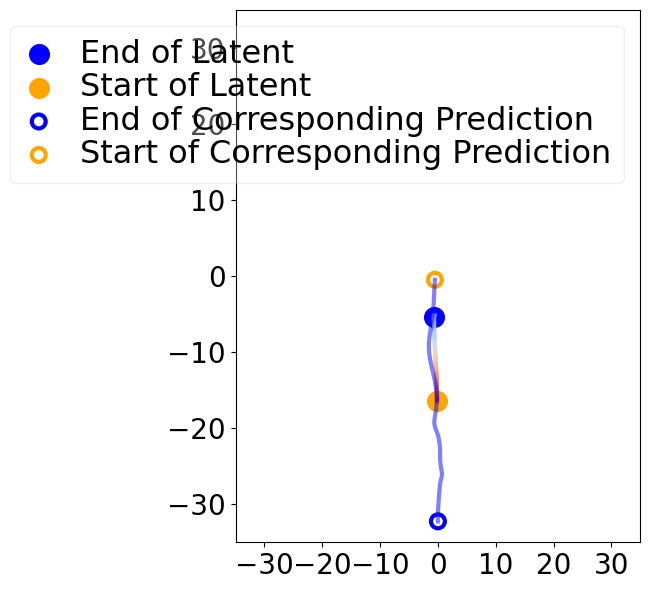

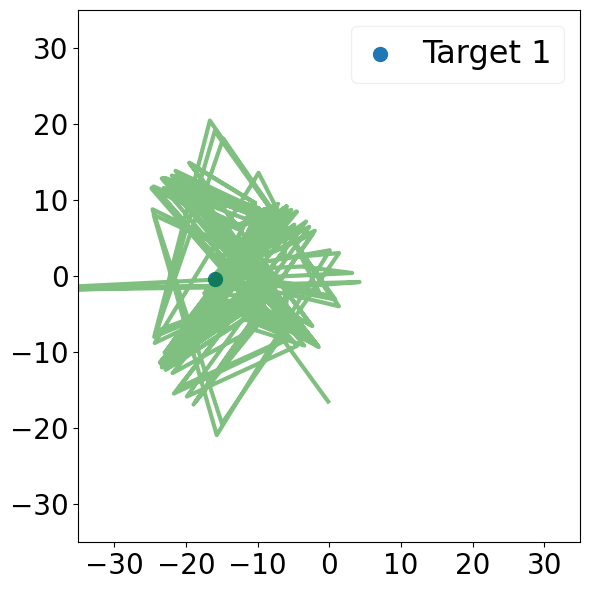

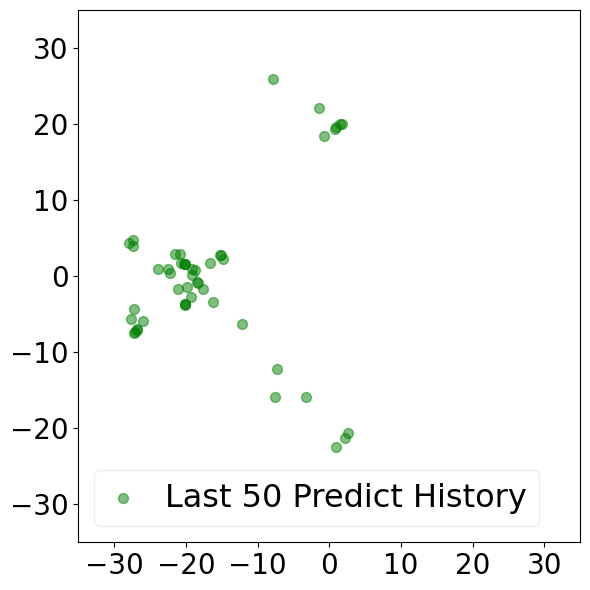

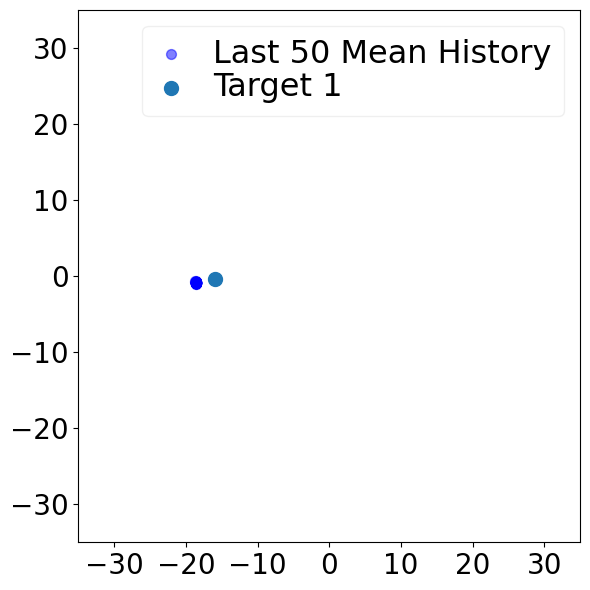

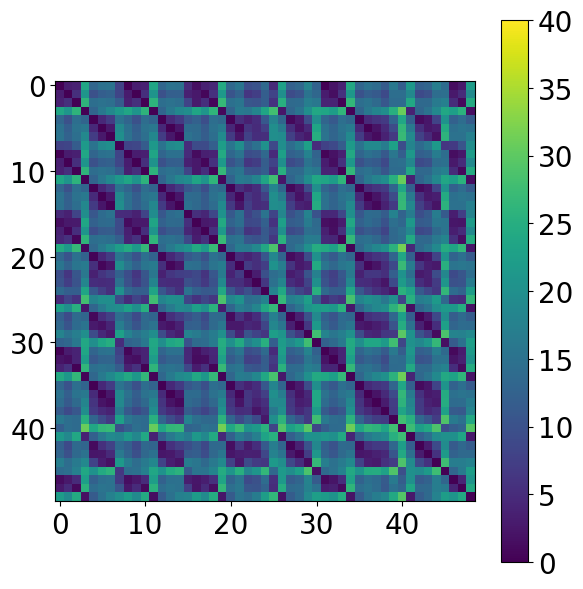

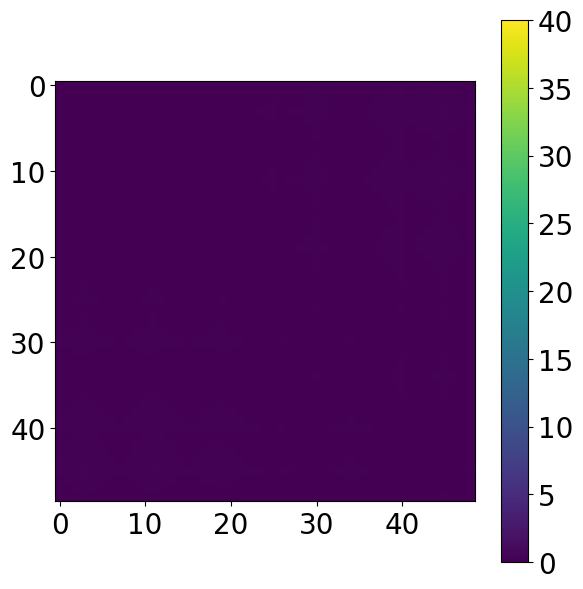

In [35]:
seed = 666
inv_scale = 0.4


# seed 22 is good enough, seed 3 also good
torch.manual_seed(seed)

x_0 = samples_0.detach().clone()[torch.randperm(len(samples_0))]
x_1 = samples_1.detach().clone()[torch.randperm(len(samples_1))]
x_pairs = torch.stack([x_0, x_1], dim=1)
print(x_pairs.shape)

################# parameter input
z0 = x_0
z1 = x_1
# Randomly select half of the points from z1
num_points = z1.shape[0]
half_points = num_points // 5
random_indices = torch.randperm(num_points)[:half_points]
zk = z1[random_indices].clone()

print(f"Shape of z1: {z1.shape}")
print(f"Shape of zk: {zk.shape}")

N = 100    # N is for timestep
M = 35
#################

################ # first sample a path
sampled_point = x_0[torch.randint(0, x_0.size(0), (1,))].to("cuda")
print(sampled_point.shape)
batchsize = sampled_point.shape[0]

dt = 1./N
traj = [] # to store the trajectory
z = sampled_point
traj.append(z.detach().clone())
for i in range(N):
  t = torch.ones((batchsize,1)) * i / N
  t = t.to("cuda")
  pred = rectified_flow_1.model(z, t)
  z = z.detach().clone() + pred * dt
  traj.append(z.detach().clone())

traj_single = traj

################ # inversion   # ? + model(?) = z
NN = 100
dtt = 1./NN
traj = [] # to store the trajectory
inv_history = []

z = traj_single[-1]
traj.append(z.detach().clone())
for i in range(NN):
  t = torch.ones((batchsize,1)) * i / NN
  t = t.to("cuda")
  t = 1-t
  print(t)
  pred = rectified_flow_1.model(z, t)

  inv_z = z.detach().clone() + pred 
  inv_history.append(inv_z.detach().clone())
  
  z = z.detach().clone() - pred * dtt
  traj.append(z.detach().clone())

traj_inversion = inv_history 

from matplotlib.lines import Line2D

# Distribution plot
plt.figure(figsize=(6,6))
plt.xlim(-M, M)
plt.ylim(-M, M)
plt.scatter(z0[:, 0].cpu().numpy(), z0[:, 1].cpu().numpy(), label=r'Source Distribution $\pi_0$', alpha=0.15, s=100)
plt.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(), label=r'Target Distribution $\pi_1$', alpha=0.15, s=100)
plt.scatter(zk[:, 0].cpu().numpy(), zk[:, 1].cpu().numpy(), label='Flow Generated', alpha=0.15, s=30)

legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#1f77b4', markeredgecolor='none', markersize=14),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#ff7f0e', markeredgecolor='none', markersize=14),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#2ca02c', markeredgecolor='none', markersize=14),
]
plt.legend(
    legend_elements,
    [r'Source Distribution $\pi_0$', r'Target Distribution $\pi_1$', 'Flow Generated'],
    fontsize=23,
    handlelength=1.0,
    labelspacing=0.08,
    frameon=True,
    framealpha=0.3
)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

# Single Trajectory plot
plt.figure(figsize=(6,6))
plt.xlim(-M, M)
plt.ylim(-M, M)
traj_array = torch.stack(traj_single).squeeze().cpu().numpy()
colors = plt.cm.coolwarm(np.linspace(0, 1, len(traj_array)))
for i in range(len(traj_array) - 1):
    plt.plot(traj_array[i:i+2, 0], traj_array[i:i+2, 1], color=colors[i], alpha=0.5, linewidth=3)
plt.scatter(traj_array[0, 0], traj_array[0, 1], color='blue', label='Start', s=200)
plt.scatter(traj_array[-1, 0], traj_array[-1, 1], color='orange', label='End', s=200)
plt.legend(
    fontsize=23,
    handlelength=1.0,
    labelspacing=0.08,
    frameon=True,
    framealpha=0.3
)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

# Inversion Trajectory plot
plt.figure(figsize=(6,6))
plt.xlim(-M, M)
plt.ylim(-M, M)
traj_array = torch.stack(traj_single).squeeze().cpu().numpy()
colors = plt.cm.coolwarm(np.linspace(0, 1, len(traj_array)))
for i in range(len(traj_array) - 1):
    plt.plot(traj_array[i:i+2, 0], traj_array[i:i+2, 1], color=colors[i], alpha=0.5, linewidth=3)
plt.scatter(traj_array[0, 0], traj_array[0, 1], color='blue', label='End of Latent', s=200)
plt.scatter(traj_array[-1, 0], traj_array[-1, 1], color='orange', label='Start of Latent', s=200)

traj_inversion_array = torch.stack(traj_inversion).squeeze().cpu().numpy()
plt.plot(traj_inversion_array[:, 0], traj_inversion_array[:, 1], 'b-', alpha=0.5, linewidth=3)
plt.scatter(traj_inversion_array[0, 0], traj_inversion_array[0, 1], facecolors='none', edgecolors='blue', label='End of Corresponding Prediction', s=100, linewidth=3)
plt.scatter(traj_inversion_array[-1, 0], traj_inversion_array[-1, 1], facecolors='none', edgecolors='orange', label='Start of Corresponding Prediction', s=100, linewidth=3)
plt.legend(
    fontsize=23,
    handlelength=1.0,
    labelspacing=0.08,
    frameon=True,
    framealpha=0.3
)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

num_experiments = len([1])

for experiment in range(1, num_experiments + 1):
    traj = []  # to store the trajectory
    predict_history = []
    predict_mean_history = []

    z = traj_single[-1]
    
    # Randomly select 'experiment' number of distributions from mvn_list
    mvn_indices = torch.randperm(len(mvn_list))[:experiment]
    selected_mvns = [mvn_list[i] for i in mvn_indices]

    # Sample one point from each selected distribution
    targets = [mvn.sample((1,)).to('cuda') for mvn in selected_mvns]
    
    z_target = torch.clone(traj_single[-1]).detach()

    traj.append(z.detach().clone())
    for i in range(300):
        t = inv_scale*torch.ones((batchsize,1)) 
        t = t.to("cuda")
        pred = rectified_flow_1.model(z, t)
        
        predict_z = z.detach().clone() + pred

        predict_history.append(predict_z.detach().clone())
        mean = torch.mean(torch.stack(traj), dim=0).detach().clone()
        pred_mean = rectified_flow_1.model(mean, t)
        predict_mean_history.append(mean + pred_mean)

        for j in range(experiment):
            if i % experiment == j:
                z_target = targets[j]

        z = z_target - pred 
        traj.append(z.detach().clone())

    # Trajectory of Latents plot
    plt.figure(figsize=(6,6))
    plt.xlim(-M, M)
    plt.ylim(-M, M)
    traj_fixedpoint_array = torch.stack(traj).squeeze().cpu().numpy()
    plt.plot(traj_fixedpoint_array[:, 0], traj_fixedpoint_array[:, 1], 'g-', alpha=0.5, linewidth=3)
    for j, target in enumerate(targets):
        target_array = target.cpu().numpy()
        plt.scatter(target_array[:, 0], target_array[:, 1], c=f'C{j}', s=100, label=f'Target {j+1}')
    plt.legend(
        fontsize=23,
        handlelength=1.0,
        labelspacing=0.08,
        frameon=True,
        framealpha=0.3
    )
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

    # Predict History plot
    plt.figure(figsize=(6,6))
    plt.xlim(-M, M)
    plt.ylim(-M, M)
    predict_history_array = torch.stack(predict_history).squeeze().cpu().numpy()
    last_100_points = predict_history_array[-50:] if len(predict_history_array) > 50 else predict_history_array
    plt.scatter(last_100_points[:, 0], last_100_points[:, 1], c='g', alpha=0.5, s=50, label='Last 50 Predict History')
    plt.legend(
        fontsize=23,
        handlelength=1.0,
        labelspacing=0.08,
        frameon=True,
        framealpha=0.3
    )
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

    # Mean Predicts plot
    plt.figure(figsize=(6,6))
    plt.xlim(-M, M)
    plt.ylim(-M, M)
    predict_mean_history_array = torch.stack(predict_mean_history).squeeze().detach().cpu().numpy()
    last_50_points = predict_mean_history_array[-50:] if len(predict_mean_history_array) > 50 else predict_mean_history_array
    plt.scatter(last_50_points[:, 0], last_50_points[:, 1], c='b', alpha=0.5, s=50, label='Last 50 Mean History')
    target_array = targets[0].cpu().numpy()
    plt.scatter(target_array[:, 0], target_array[:, 1], c='C0', s=100, label='Target 1')
    plt.legend(
        fontsize=23,
        handlelength=1.0,
        labelspacing=0.08,
        frameon=True,
        framealpha=0.3
    )
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

    # Pairwise distances plot
    plt.figure(figsize=(6,6))
    V_history = traj
    N = len(V_history)
    norms = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            norms[i,j] = torch.linalg.norm(V_history[i] - V_history[j])
    im = plt.imshow(norms[-50:-1, -50:-1], cmap='viridis', interpolation='nearest', vmin=0, vmax=40)
    cbar = plt.colorbar(im)
    cbar.ax.tick_params(labelsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

    # Mean predictions pairwise distances plot
    plt.figure(figsize=(6,6))
    V_history = predict_mean_history
    N = len(V_history)
    norms = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            norms[i,j] = torch.linalg.norm(V_history[i] - V_history[j])
    im = plt.imshow(norms[-50:-1, -50:-1], cmap='viridis', interpolation='nearest', vmin=0, vmax=40)
    cbar = plt.colorbar(im)
    cbar.ax.tick_params(labelsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

# finetune

In [19]:
# ################ # fixed point   # ? + model(?) = z
# traj = [] # to store the trajectory
# predict_history = []

# z = traj_single[-1]
# z = torch.tensor([[-3, 3]], dtype=torch.float32, device='cuda')

# #z = torch.tensor([[2, 0]], dtype=torch.float32, device='cuda')
# z_target = torch.clone(z).detach()

# z = torch.clone(z).detach()
# # Define the target point
# target = torch.tensor([[3, 3]], dtype=torch.float32, device='cuda')
# # Create an optimizer for the model parameters
# optimizer = torch.optim.Adam(rectified_flow_1.model.parameters(), lr=0.0001)
# # Number of optimization steps
# num_steps = 100
# for step in range(num_steps):
#     optimizer.zero_grad()
#     t = 0.3 * torch.ones((1, 1), device='cuda')
#     pred = rectified_flow_1.model(z, t)
#     predict_z = z + pred
#     # Compute loss as the distance between predict_z and the target
#     loss = torch.nn.functional.mse_loss(predict_z, target)
#     # Backpropagate and update model parameters
#     loss.backward()
#     optimizer.step()

#     if step % 10 == 0:
#         print(f"Step {step}, Loss: {loss.item():.4f}, Predict_z: {predict_z.detach().cpu().numpy()}")



We run the Euler method to solve the ODE with $N=1000$ steps to generate samples from 1-Rectified Flow.

Orange dots = samples from $\pi_0$

Blue dots   = samples from $\pi_1$

Green dots  = samples from 1-Rectified Flow

1-Rectified Flow successfully learned a velocity field $v(Z_t, t)$ that can transport $\pi_0$ to $\pi_1$.

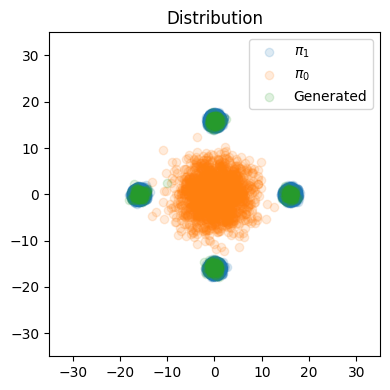

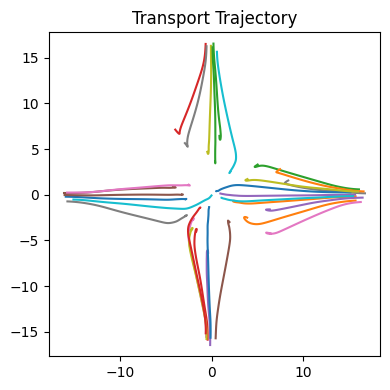

In [20]:
draw_plot(rectified_flow_1, z0=samples_0[torch.randperm(len(samples_0))[:2000]].to("cuda"), z1=samples_1.detach().clone(), N=100)

We can see that the trajectories above fit well on the trajectories of linear intepolation of data, but are "rewired" in the center when the trajectories are intersect. Hence, the resulting trajectories are either (almost)straight, or has a ">" shape.

Due to the non-straight ">"-shape paths, if we simulate the ODE with a small step $N$, we would obtain poor performance, as shown below ($N=1$).

## Reflow for 2-Rectified Flow
Now let's use the *reflow* procedure to get a straightened rectified flow,
denoted as 2-Rectified Flow, by repeating the same procedure on with $(X_0,X_1)$ replaced by  $(Z_0^1, Z_1^1)$, where   $(Z_0^1, Z_1^1)$ is the coupling simulated from 1-Rectified Flow.  
Specifically, we randomly sample 10000 $Z_0^1$  and generate their corresponding  $Z_1^1$ by simulating 1-Rectified Flow.

In [21]:
z10 = samples_0.detach().clone().to("cuda")
traj = rectified_flow_1.sample_ode(z0=z10.detach().clone(), N=100)
z11 = traj[-1].detach().clone()
z_pairs = torch.stack([z10, z11], dim=1)
print(z_pairs.shape)

torch.Size([100000, 2, 2])


The coupling $(Z_0^1, Z_1^1)$ is now deterministic. The loss function is:
$$
\min_{\theta}
\int_0^1 E_{(Z_0, Z_1) \sim (Z_0^1, Z_1^1)} \left [ {||( Z_1 - Z_0) - v_\theta\big (Z_t,~ t\big)||}^2
\right ] \text{d}t,
~~~~~\text{with}~~~~
Z_t = t Z_1 + (1-t) Z_0.
$$

We create ```rectified_flow_2``` and its corresponding ```optimizer``` and traing 2-Rectified Flow with ```train_rectified_flow```.

We use the model pretrained in 1-Rectified Flow to accelerate training.

In [22]:
print(z_pairs.device)

cuda:0


In [23]:
reflow_iterations = 50000

# Determine the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the model and move it to the device
rectified_flow_2 = RectifiedFlow(model=MLP(input_dim, hidden_num=100), num_steps=100)

import copy
# Copy the previous model and move it to the device
# rectified_flow_2.net = copy.deepcopy(rectified_flow_1)

rectified_flow_2.model = copy.deepcopy(rectified_flow_1.model)





# Create the optimizer
optimizer = torch.optim.Adam(rectified_flow_2.model.parameters(), lr=5e-3)

# Ensure z_pairs is on the correct device
z_pairs = z_pairs.to(device)

# Train the model
rectified_flow_2, loss_curve = train_rectified_flow(rectified_flow_2, optimizer, z_pairs, batchsize, reflow_iterations)

# Plot the loss curve
plt.plot(np.linspace(0, reflow_iterations, reflow_iterations+1), loss_curve[:(reflow_iterations+1)])

KeyboardInterrupt: 

We run the Euler method to solve the ODE with $N=100$ steps to generate samples from 2-Rectified Flow.

2-Rectified Flow can also successfully learn a velocity field $v(Z_t, t)$ that can transport $\pi_0$ to $\pi_1$.

The key point, however, is that the transport trajectory is now **straightened** and hence we would not lose much accuracy even if we solve the ODE with one Euler step ($N=1$).

In [ ]:
x_0 = samples_0.detach().clone()[torch.randperm(len(samples_0))]
x_1 = samples_1.detach().clone()[torch.randperm(len(samples_1))]
x_pairs = torch.stack([x_0, x_1], dim=1)
print(x_pairs.shape)


################# parameter input
z0 = x_0
z1 = x_1
N = 100    # N is for timestep
M = 35
#################


################ # first sample a path
#  pred = rectified_flow.model(z_t, t) # print(z_t.shape) torch.Size([2048, 2]) # print(t.shape) torch.Size([2048, 1])
torch.manual_seed(222)
# Set the random seed for reproducibility
# Sample a single point from x_0
sampled_point = x_0[torch.randint(0, x_0.size(0), (1,))].to("cuda")
print(sampled_point.shape)
batchsize = sampled_point.shape[0]


dt = 1./N
traj = [] # to store the trajectory
z = sampled_point
traj.append(z.detach().clone())
for i in range(N):
  t = torch.ones((batchsize,1)) * i / N
  t = t.to("cuda")
  pred = rectified_flow_1.model(z, t)
  z = z.detach().clone() + pred * dt
  traj.append(z.detach().clone())

traj_single = traj


################ # inversion   # ? + model(?) = z
NN = 100
dtt = 1./NN
traj = [] # to store the trajectory
inv_history = []

z = traj_single[-1]
traj.append(z.detach().clone())
for i in range(NN):
  t = torch.ones((batchsize,1)) * i / NN
  t = t.to("cuda")
  t = 1-t
  print(t)
  pred = rectified_flow_1.model(z, t)


  inv_z = z.detach().clone() + pred 
  inv_history.append(inv_z.detach().clone())
  
  z = z.detach().clone() - pred * dtt
  traj.append(z.detach().clone())

traj_inversion = traj






###################################################################################################
# Create a figure with six subplots arranged in 2 rows and 3 columns
 
fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(30, 10))

# First subplot: Distribution
ax1.set_xlim(-M, M)
ax1.set_ylim(-M, M)

ax1.scatter(z0[:, 0].cpu().numpy(), z0[:, 1].cpu().numpy(), label=r'$\pi_0$', alpha=0.15, s=100)
ax1.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(), label=r'$\pi_1$', alpha=0.15, s=100)
ax1.scatter(traj_single[-1][:, 0].cpu().numpy(), traj_single[-1][:, 1].cpu().numpy(), label='Generated', alpha=0.15, s=100)
ax1.legend()
ax1.set_title('Distribution')

# Second subplot: Single Trajectory
ax2.set_xlim(-M, M)
ax2.set_ylim(-M, M)

traj_array = torch.stack(traj_single).squeeze().cpu().numpy()
ax2.plot(traj_array[:, 0], traj_array[:, 1], 'r-', alpha=0.5, linewidth=3)
ax2.scatter(traj_array[0, 0], traj_array[0, 1], c='b', label='Start', s=200)
ax2.scatter(traj_array[-1, 0], traj_array[-1, 1], c='g', label='End', s=200)
ax2.legend()
ax2.set_title('Single Trajectory')

# Third subplot: Inversion Trajectory
ax3.set_xlim(-M, M)
ax3.set_ylim(-M, M)

traj_inversion_array = torch.stack(traj_inversion).squeeze().cpu().numpy()
ax3.plot(traj_inversion_array[:, 0], traj_inversion_array[:, 1], 'b-', alpha=0.5, linewidth=3)
ax3.scatter(traj_inversion_array[0, 0], traj_inversion_array[0, 1], c='r', label='Start', s=200)
ax3.scatter(traj_inversion_array[-1, 0], traj_inversion_array[-1, 1], c='g', label='End', s=200)

plt.tight_layout()
plt.show()

# Plot points in inv_history as scatter points

################ # fixed point   # ? + model(?) = z
num_experiments = len(mvn_list)

for experiment in range(1, num_experiments + 1):
    fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(30, 10))


    traj = []  # to store the trajectory
    predict_history = []

    z = traj_single[-1]
    #z = torch.tensor([[3, 3]], dtype=torch.float32, device='cuda')
    
    # Randomly select 'experiment' number of distributions from mvn_list
    mvn_indices = torch.randperm(len(mvn_list))[:experiment]
    selected_mvns = [mvn_list[i] for i in mvn_indices]

    # Sample one point from each selected distribution
    targets = [mvn.sample((1,)).to('cuda') for mvn in selected_mvns]
    
    z_target = torch.clone(traj_single[-1]).detach()

    traj.append(z.detach().clone())
    for i in range(300):
        t = 0.2*torch.ones((batchsize,1)) 
        t = t.to("cuda")
        pred = rectified_flow_1.model(z, t)
        
        predict_z = z.detach().clone() + pred 
        predict_history.append(predict_z.detach().clone())

        for j in range(experiment):
            if i % experiment == j:
                z_target = targets[j]

        z = z_target - pred 
        traj.append(z.detach().clone())


    # Update the plotting code for each experiment
    ax1.set_xlim(-M, M)
    ax1.set_ylim(-M, M)

    traj_fixedpoint_array = torch.stack(traj).squeeze().cpu().numpy()
    ax1.plot(traj_fixedpoint_array[:, 0], traj_fixedpoint_array[:, 1], 'g-', alpha=0.5, linewidth=3)
    
    # Plot the target points
    for j, target in enumerate(targets):
        target_array = target.cpu().numpy()
        ax1.scatter(target_array[:, 0], target_array[:, 1], c=f'C{j}', s=200, label=f'Target {j+1}')
    
    ax1.legend()
    ax1.set_title(f'Fixed Point Trajectory Group of {experiment}')

    # Fifth subplot: Predict History (using the last experiment's predict_history)
    ax2.set_xlim(-M, M)
    ax2.set_ylim(-M, M)
    predict_history_array = torch.stack(predict_history).squeeze().cpu().numpy()
    # Plot only the last 100 points in predict_history as green
    last_100_points = predict_history_array[-50:] if len(predict_history_array) > 50 else predict_history_array
    ax2.scatter(last_100_points[:, 0], last_100_points[:, 1], c='g', alpha=0.5, s=100, label='Last 50 Predict History')
    ax2.legend()
    ax2.set_title(f'Last 50 Points of Predict History Group of {experiment}')

    # Sixth subplot: Heatmap of pairwise distances (using the last experiment's trajectory)
    V_history = traj
    N = len(V_history)
    norms = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
                norms[i,j] = torch.linalg.norm(V_history[i] - V_history[j])
    im = ax3.imshow(norms[-50:-1, -50:-1], cmap='viridis', interpolation='nearest')
    # Add color bar to show the scale
    plt.colorbar(im, ax=ax3)
    ax3.set_title(f'Pairwise Distances Group of {experiment}')

    plt.tight_layout()
    plt.show()


In [ ]:
draw_plot(rectified_flow_2, z0=samples_0[torch.randperm(len(samples_0))[:2000]].to("cuda"), z1=samples_1.detach().clone())

So below is the result when we solve the ODE with $N=1$ Euler step to generate samples from 2-Rectified Flow.

With the **straightened** trajectory, we get almost perfect results with only  one-step generation! Thanks to the power of **Reflow** !

More croncretely, the output of the model is now $Z_1 = Z_0 + v(Z_0, 0)$.

Effectively, we have trained a one-step model, by using ODE as an intermediate step.

In [ ]:
draw_plot(rectified_flow_2, z0=initial_model.sample([1000]), z1=samples_1.detach().clone(), N=1)